In [2]:
#Prove integral with decay 210-Po#
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad, simpson, dblquad
from scipy.interpolate import InterpolatedUnivariateSpline
from scipy.optimize import brentq

Z_alpha=2
Z_daugther=82
e2=1.44
a_0=0.54
alpha=0.7024
beta=0.22
A_alpha=4
A_daugther=206
x=7999/4
y=2134/2.5
R_0=1.07*(A_daugther)**(1/3)
beta2 = 0.0
beta4 = 0.008
J00=-275
Q_alpha = 5.407
hbarc = 197.327
L = 0
G = 18
B = (G - L + 1) * (np.pi / 2)
m_n = 931.5
muc2=(A_daugther*A_alpha)/(A_daugther+A_alpha)*m_n
zpb=(muc2*(beta)**2)/(2*(hbarc)**2)

#----------------------CONSTRUCCION DE POTENCIAL NUCLEAR--------------------------------------------------

#Normalizacion del valor del valor la densidad de la hija
def Y00(theta):
    return np.sqrt(1/(4*np.pi))
def Y20(theta):
    return (1/4)*(np.sqrt(5/np.pi))*(3*(np.cos(theta))**2-1)
def Y40(theta):
    return (3/16) * (np.sqrt(1/np.pi)) * (35*(np.cos(theta))**4-30*(np.cos(theta))**2+3)

def R_f_theta(theta):    
    return R_0*(1+beta2*Y20(theta)+beta4*Y40(theta))

def a_f_theta(theta):
    a_perpendicular=a_0*(1+beta2*Y20(theta)+beta4*Y40(theta))
    gradR=(R_0/R_f_theta(theta))*(-(3/2)*(np.sqrt(5/np.pi))*beta2*np.cos(theta)*np.sin(theta)
                           -(105/4)*(np.sqrt(1/np.pi))*beta4*
                           (np.cos(theta))**3*np.sin(theta)+(45/4)*(np.sqrt(1/np.pi))*beta4
                           *np.cos(theta)*np.sin(theta))
    return a_perpendicular*(np.sqrt(1+(np.abs(gradR)**2)))
#Normalizacion  
def rho2(theta,r):    
    argumento=1/ (1+np.exp((r-R_f_theta(theta))/(a_f_theta(theta))))
    return argumento*r**2*np.sin(theta)
I_rho2=dblquad(rho2, 0.01 , 15, lambda r:0, lambda r: np.pi)
rho2_normalizado=A_daugther/(2*np.pi*I_rho2[0])


#------------FURIER TRASNFORM----------------------

#Mine Values
rmalla = np.linspace(0.01, 25, 500)
theta=np.linspace(0,np.pi,250)
r2, Theta = np.meshgrid(rmalla, theta, indexing='ij')
k = np.linspace(0.001, 25, 400)

####---------------Bessel Funtion------------

def j0(r2,k):
    return (np.sin(k*r2))/(k*r2)

def j2(r2,k):
    x = k*r2
    return ((3/(x)**2)-1)*((np.sin(x))/(x))-3*((np.cos(x))/(x)**2)

def j4(r2,k):
    x = k*r2
    return (((105)/(x)**5)-((45)/(x)**3)+(1/(x)))*np.sin(x)-(((105)/(x)**4)-((10)/(x)**2))*np.cos(x)


rho2_furiernuclear0=[]
for ki in k:
    rho2_integral0=2*np.pi*rho2_normalizado*j0(r2,ki)*Y00(Theta)*r2**2*np.sin(Theta)*(1/(1+np.exp((r2-R_f_theta(Theta))/(a_f_theta(Theta)))))
    integral_r0 = simpson(rho2_integral0, x=rmalla, axis=0)   
    integral_completa0 = simpson(integral_r0, x=theta)      
    rho2_furiernuclear0.append(integral_completa0)    
rho2_fnuclear0=np.array(rho2_furiernuclear0)



rho2_furiernuclear2=[]
for ki in k:
    rho2_integral2=2*np.pi*rho2_normalizado*j2(r2,ki)*Y20(Theta)*r2**2*np.sin(Theta)*(1/(1+np.exp((r2-R_f_theta(Theta))/(a_f_theta(Theta)))))
    integral_r2 = simpson(rho2_integral2, x=rmalla, axis=0)   
    integral_completa2 = simpson(integral_r2, x=theta)      
    rho2_furiernuclear2.append(integral_completa2)    
rho2_fnuclear2=np.array(rho2_furiernuclear2)


rho2_furiernuclear4=[]
for ki in k:
    rho2_integral4=2*np.pi*rho2_normalizado*j4(r2,ki)*Y40(Theta)*r2**2*np.sin(Theta)*(1/(1+np.exp((r2-R_f_theta(Theta))/(a_f_theta(Theta)))))
    integral_r4 = simpson(rho2_integral4, x=rmalla, axis=0)   
    integral_completa4 = simpson(integral_r4, x=theta)      
    rho2_furiernuclear4.append(integral_completa4)    
rho2_fnuclear4=np.array(rho2_furiernuclear4)




#Ahora de la particula alfa, que será la esferica 
rho1_furiernuclear=0.4228*(np.pi/alpha)**(1.5)*np.exp(-k**2/(4*alpha))

#Transformada del potencial nuclear

R=np.linspace(0.05,30,800)
phi = np.linspace(0, np.pi, 600)

def j0N(R,k):
    return (np.sin(k*R))/(k*R)

def j2N(R,k):
    x = k*R
    return ((3/(x)**2)-1)*((np.sin(x))/(x))-3*((np.cos(x))/(x)**2)

def j4N(R,k):
    x = k*R
    return (((105)/(x)**5)-((45)/(x)**3)+(1/(x)))*np.sin(x)-(((105)/(x)**4)-((10)/(x)**2))*np.cos(x)

#L=0
V_NN0=[]
for Ri in R:
    g=(x/((k**2)+4**2))-(y/((k**2)+(2.5)**2))# + J00/(4*np.pi)
    V_Fold0 =(2/np.pi) *((1)/(np.sqrt(4*np.pi)))* rho1_furiernuclear * rho2_fnuclear0 *j0N(Ri,k)*k**2*(4*np.pi*g)
    V_NN0.append(simpson(V_Fold0,k))
V_NN0=np.array(V_NN0)

#L=2
def P2(phi):
    return 0.5*(3*np.cos(phi)**2 - 1)


V_NN2=[]
for Ri in R:
    g=(x/((k**2)+4**2))-(y/((k**2)+(2.5)**2))# + J00/(4*np.pi)
    V_Fold2 =(2/np.pi)*np.sqrt((5/(4*np.pi))) * rho1_furiernuclear * rho2_fnuclear2 *j2N(Ri,k)*k**2*(4*np.pi*g)
    V_NN2.append(simpson(V_Fold2,k))
V_NN2=np.array(V_NN2)


V2_NN = V_NN2[:, None] * P2(phi)[None, :]
#L=4
def P4(phi):
    return (1/8)*(35*(np.cos(phi))**4 -30*(np.cos(phi))**2+3)


V_NN4=[]
for Ri in R:
    g=(x/((k**2)+4**2))-(y/((k**2)+(2.5)**2))# + J00/(4*np.pi)
    V_Fold4 =(2/np.pi)*np.sqrt((9/(4*np.pi))) * rho1_furiernuclear * rho2_fnuclear4 *j4N(Ri,k)*k**2*(4*np.pi*g)
    V_NN4.append(simpson(V_Fold4,k))
V_NN4=np.array(V_NN4)


V4_NN = V_NN4[:, None] * P4(phi)[None, :]

#print(V_NN)
V_Nuclear=V_NN0[:, None]+V2_NN+V4_NN



#Construccion de potencial de Coulomb el cual tambien dependera del radio y del ángulo 
#normalizacion de carga alfa
def I1(r1):
    I_rho_alphacoulomb=r1**2*np.exp(-alpha*r1**2)
    return I_rho_alphacoulomb
I_solve1=quad(I1, 0, 15)
rho1_normalizadocoulomb=(Z_alpha)/(4*np.pi*I_solve1[0])

#normalizacion de carga Z=82


def rho2coulomb(theta,r):    
    argumento=1/ (1+np.exp((r-R_f_theta(theta))/(a_f_theta(theta))))
    return argumento*r**2*np.sin(theta)
I_rho2=dblquad(rho2coulomb, 0.01 , 15, lambda r:0, lambda r: np.pi)
rho2_normalizadocoulomb=Z_daugther/(2*np.pi*I_rho2[0])

#Fourier Transform alfa
rho1_furiercoulomb=rho1_normalizadocoulomb*(np.pi/alpha)**(1.5)*np.exp(-k**2/(4*alpha))

rho2_furiercoulomb0=[]
for ki in k:
    rho2_integral0coulomb=2*np.pi*rho2_normalizadocoulomb*j0(r2,ki)*Y00(Theta)*r2**2*np.sin(Theta)*(1/(1+np.exp((r2-R_f_theta(Theta))/(a_f_theta(Theta)))))
    integral_r0coulomb = simpson(rho2_integral0coulomb, x=rmalla, axis=0)   
    integral_completa0coulomb = simpson(integral_r0coulomb, x=theta)      
    rho2_furiercoulomb0.append(integral_completa0coulomb)    
rho2_fcoulomb0=np.array(rho2_furiercoulomb0)



rho2_furiercoulomb2=[]
for ki in k:
    rho2_integral2coulomb=2*np.pi*rho2_normalizadocoulomb*j2(r2,ki)*Y20(Theta)*r2**2*np.sin(Theta)*(1/(1+np.exp((r2-R_f_theta(Theta))/(a_f_theta(Theta)))))
    integral_r2coulomb = simpson(rho2_integral2coulomb, x=rmalla, axis=0)   
    integral_completa2coulomb = simpson(integral_r2coulomb, x=theta)      
    rho2_furiercoulomb2.append(integral_completa2coulomb)    
rho2_fcoulomb2=np.array(rho2_furiercoulomb2)


rho2_furiercoulomb4=[]
for ki in k:
    rho2_integral4coulomb=2*np.pi*rho2_normalizadocoulomb*j4(r2,ki)*Y40(Theta)*r2**2*np.sin(Theta)*(1/(1+np.exp((r2-R_f_theta(Theta))/(a_f_theta(Theta)))))
    integral_r4coulomb = simpson(rho2_integral4coulomb, x=rmalla, axis=0)   
    integral_completa4coulomb = simpson(integral_r4coulomb, x=theta)      
    rho2_furiercoulomb4.append(integral_completa4coulomb)    
rho2_fcoulomb4=np.array(rho2_furiercoulomb4)

#--------------Potencial trasnformado-----------------------
#L=0
V_C0=[]
for Ri in R:
    V_Fold = (2*e2/np.pi) *((4*np.pi)/np.sqrt(4*np.pi))* rho1_furiercoulomb * rho2_fcoulomb0 * j0N(Ri,k)
    V_C0.append(simpson(V_Fold,k))
V0_C=np.array(V_C0)
#L=2
V_C2=[]
for Ri in R:
    V_Fold2 = (2*e2/np.pi)*4*np.pi *np.sqrt((5)/(4*np.pi))* rho1_furiercoulomb * rho2_fcoulomb2 * j2N(Ri,k)
    V_C2.append(simpson(V_Fold2,k))
V_C2=np.array(V_C2)

V2_C = V_C2[:, None] * P2(phi)[None, :]
#L=4
V_C4=[]
for Ri in R:
    V_Fold4 = (2*e2/np.pi) *4*np.pi*(np.sqrt((9)/(4*np.pi))) *rho1_furiercoulomb * rho2_fcoulomb4 * j4N(Ri,k)
    V_C4.append(simpson(V_Fold4,k))
V_C4=np.array(V_C4)

V4_C = V_C4[:, None] * P4(phi)[None, :]

V_Coulomb=V0_C[:,None]+V2_C+V4_C


#Centrifuco
V_L  = (hbarc**2 / (2 * muc2)) * ((L + 0.5)**2 /( R**2))

def action(lam):
    for V_Coulombi, V_Li, V_Nucleari in zip(V_Coulomb, V_L, V_Nuclear):
        V=lam*V_Nucleari + V_Coulombi + V_Li
        s=InterpolatedUnivariateSpline(R, Q_alpha - V, k=3)
        roots=s.roots()
        if len(roots)<2:
            return None
        r1, r2 = roots[0], roots[1]
        f= lambda r: np.sqrt((2*muc2/hbarc**2)*s(r))
        return quad(f, r1, r2, limit=200)[0]
        
lamdas = np.linspace(0.5, 3, 3000)
vals = [(lam, action(lam)) for lam in lamdas]
#vals = [(l,I) for l,I in vals if I is not None]

lam_opt = min(vals, key=lambda x: abs(x[1]-B))[0]
print("lambda =", np.round(lam_opt,3))
        


ValueError: x and y should have a same length

In [1]:
# Prove integral with decay 236-U
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad, simpson, dblquad
from scipy.interpolate import InterpolatedUnivariateSpline
from scipy.optimize import brentq
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# ─── Constantes ───────────────────────────────────────────────────────────────
Z_alpha = 2
Z_daugther = 90
e2 = 1.44
a_0 = 0.54
alpha = 0.7024
beta = 0.22
A_alpha = 4
A_daugther = 232
x = 7999 / 4
y = 2134 / 2.5
R_0 = 1.07 * (A_daugther) ** (1 / 3)
beta2 = 0.215
beta4 = 0.102
J00 = -275
Q_alpha = 4.57
hbarc = 197.327
L = 0
G = 22
B = (G - L + 1) * (np.pi / 2)
m_n = 931.5
muc2 = (A_daugther * A_alpha) / (A_daugther + A_alpha) * m_n
zpb = (muc2 * (beta) ** 2) / (2 * (hbarc) ** 2)

# ─── Armónicos esféricos y geometría de la hija ──────────────────────────────
def Y00(theta): return np.sqrt(1 / (4 * np.pi))
def Y20(theta): return (1 / 4) * np.sqrt(5 / np.pi) * (3 * np.cos(theta) ** 2 - 1)
def Y40(theta): return (3 / 16) * np.sqrt(1 / np.pi) * (35 * np.cos(theta) ** 4 - 30 * np.cos(theta) ** 2 + 3)

def R_f_theta(theta):
    return R_0 * (1 + beta2 * Y20(theta) + beta4 * Y40(theta))

def a_f_theta(theta):
    a_perp = a_0 * (1 + beta2 * Y20(theta) + beta4 * Y40(theta))
    gradR = (R_0 / R_f_theta(theta)) * (
        -(3 / 2) * np.sqrt(5 / np.pi) * beta2 * np.cos(theta) * np.sin(theta)
        - (105 / 4) * np.sqrt(1 / np.pi) * beta4 * np.cos(theta) ** 3 * np.sin(theta)
        + (45 / 4) * np.sqrt(1 / np.pi) * beta4 * np.cos(theta) * np.sin(theta)
    )
    return a_perp * np.sqrt(1 + np.abs(gradR) ** 2)

# ─── Grillas ─────────────────────────────────────────────────────────────────
rmalla = np.linspace(0.01, 25, 500)
theta = np.linspace(0, np.pi, 250)
r2, Theta = np.meshgrid(rmalla, theta, indexing='ij')

k = np.linspace(0.001, 25, 400)
R = np.linspace(0.05, 30, 800)
phi = np.linspace(0, np.pi/2, 46)

fermi_2D = 1.0 / (1.0 + np.exp((r2 - R_f_theta(Theta)) / a_f_theta(Theta)))

# ─── Funciones de Bessel ───────────────────────────────────────────
def j0_f(x): return np.sin(x) / x
def j2_f(x): return (3 / x**2 - 1) * np.sin(x) / x - 3 * np.cos(x) / x**2
def j4_f(x): return ((105 / x**5) - (45 / x**3) + (1 / x)) * np.sin(x) - ((105 / x**4) - (10 / x**2)) * np.cos(x)

# ─── Normalización ─────────────────────────────────────
def rho2_integrand(theta, r):
    return (1 / (1 + np.exp((r - R_f_theta(theta)) / a_f_theta(theta)))) * r**2 * np.sin(theta)

I_rho2, _ = dblquad(rho2_integrand, 0.01, 15, 0, np.pi)
rho2_norm = A_daugther / (2 * np.pi * I_rho2)
rho2_norm_coulomb = Z_daugther / (2 * np.pi * I_rho2)

# ─── Fourier ──────────────────────────
r3 = rmalla[:, None, None]
Th3 = theta[None, :, None]
k3 = k[None, None, :]

fermi_3D = 1.0 / (1.0 + np.exp((r3 - R_f_theta(Th3)) / a_f_theta(Th3)))
sin_Th = np.sin(Th3)

def fourier_rho2(norm, Ylm, jl, factor_4pi):
    integrand = 2 * np.pi * norm * jl(r3 * k3) * Ylm(Th3) * r3**2 * sin_Th * fermi_3D
    int_r = simpson(integrand, x=rmalla, axis=0)
    return simpson(int_r, x=theta, axis=0)

rho2_fn0 = fourier_rho2(rho2_norm, Y00, j0_f, 1)
rho2_fn2 = fourier_rho2(rho2_norm, Y20, j2_f, 1)
rho2_fn4 = fourier_rho2(rho2_norm, Y40, j4_f, 1)

rho2_fc0 = fourier_rho2(rho2_norm_coulomb, Y00, j0_f, 1)
rho2_fc2 = fourier_rho2(rho2_norm_coulomb, Y20, j2_f, 1)
rho2_fc4 = fourier_rho2(rho2_norm_coulomb, Y40, j4_f, 1)

# ─── Alfa ─────────────────────
I_r1, _ = quad(lambda r1: r1**2 * np.exp(-alpha * r1**2), 0, 15)
rho1_norm_c = Z_alpha / (4 * np.pi * I_r1)
gauss_k = np.exp(-k**2 / (4 * alpha))

rho1_fn = 0.4228 * (np.pi / alpha) ** 1.5 * gauss_k
rho1_fc = rho1_norm_c * (np.pi / alpha) ** 1.5 * gauss_k

# ─── Potenciales ────────────────────────
Rm, km = np.meshgrid(R, k, indexing='ij')
g_k = x / (k**2 + 4**2) - y / (k**2 + 2.5**2)+ (J00 / (4*np.pi))

def V_nuclear_L(rho1, rho2_fL, jLN, prefactor):
    integrand = prefactor * rho1[None, :] * rho2_fL[None, :] * jLN(Rm * km) * km**2 * (4 * np.pi * g_k[None, :])
    return (2 / np.pi) * simpson(integrand, x=k, axis=1)

V_NN0 = V_nuclear_L(rho1_fn, rho2_fn0, j0_f, 1 / np.sqrt(4 * np.pi))
V_NN2 = V_nuclear_L(rho1_fn, rho2_fn2, j2_f, np.sqrt(5 / (4 * np.pi)))
V_NN4 = V_nuclear_L(rho1_fn, rho2_fn4, j4_f, np.sqrt(9 / (4 * np.pi)))

def V_coulomb_L(rho1, rho2_fL, jLN, prefactor):
    integrand = prefactor * rho1[None, :] * rho2_fL[None, :] * jLN(Rm * km)
    return (2 * e2 / np.pi) * simpson(integrand, x=k, axis=1)

V_C0 = V_coulomb_L(rho1_fc, rho2_fc0, j0_f, 4 * np.pi / np.sqrt(4 * np.pi))
V_C2 = V_coulomb_L(rho1_fc, rho2_fc2, j2_f, 4 * np.pi * np.sqrt(5 / (4 * np.pi)))
V_C4 = V_coulomb_L(rho1_fc, rho2_fc4, j4_f, 4 * np.pi * np.sqrt(9 / (4 * np.pi)))

# ─── Ensamble ──────────────────────────────────
def P2(phi): return 0.5 * (3 * np.cos(phi)**2 - 1)
def P4(phi): return (1 / 8) * (35 * np.cos(phi)**4 - 30 * np.cos(phi)**2 + 3)

V_Nuclear = (
    V_NN0[:, None]
    + V_NN2[:, None] * P2(phi)[None, :]
    + V_NN4[:, None] * P4(phi)[None, :]
)

V_Coulomb = (
    V_C0[:, None]
    + V_C2[:, None] * P2(phi)[None, :]
    + V_C4[:, None] * P4(phi)[None, :]
)

V_L = (hbarc**2 / (2 * muc2)) * ((L + 0.5)**2 / R**2)

def accion_phi_lam(lam, phi_idx):
    V_total = lam * V_Nuclear[:, phi_idx] + V_Coulomb[:, phi_idx] + V_L
    s = InterpolatedUnivariateSpline(R, Q_alpha - V_total, k=3)
    roots = s.roots()
    if len(roots) < 2:
        return None
    r1, r2 = roots[0], roots[-1]
    f = lambda r: np.sqrt(np.abs((2 * muc2 / hbarc**2) * s(r)))
    return quad(f, r1, r2, limit=200)[0]

lam_opt_vs_phi = []

for i, ph in enumerate(phi):
    try:
        lam_opt_i = brentq(
            lambda lam: accion_phi_lam(lam, i) - B,
            a=0.5, b=3.0,
            xtol=1e-4
        )
        lam_opt_vs_phi.append((ph, lam_opt_i))
        print(f"φ = {np.degrees(ph):6.1f}° → λ = {lam_opt_i:.4f}")
    except (ValueError, TypeError):
        lam_opt_vs_phi.append((ph, None))
        print(f"φ = {np.degrees(ph):6.1f}° → sin solución")

# ─── GRÁFICAS (corregida indentación loops) ─────────────────────

for pidx, lbl, col in zip(phi_idxs, phi_lbls, colors_ph):
    axs[1,1].plot(R, V_Nuclear[:, pidx], lw=2, label=lbl, color=col)

for pidx, lbl, col in zip(phi_idxs, phi_lbls, colors_ph):
    axs[1,2].plot(R, V_Coulomb[:, pidx], lw=2, label=lbl, color=col)

for pidx, lbl, col in zip(phi_idxs, phi_lbls, colors_ph):
    V_tot = lam_interp[pidx]*V_Nuclear[:,pidx] + V_Coulomb[:,pidx] + V_L
    axs[2,0].plot(R, V_tot, lw=2, label=lbl, color=col)

for pidx, lbl, col in zip(phi_idxs, phi_lbls, colors_ph):
    V_tot = lam_interp[pidx]*V_Nuclear[:,pidx] + V_Coulomb[:,pidx] + V_L
    axins.plot(R, V_tot, lw=1.5, color=col)

plt.show()


φ =    0.0° → sin solución
φ =    2.0° → sin solución
φ =    4.0° → sin solución
φ =    6.0° → sin solución
φ =    8.0° → sin solución
φ =   10.0° → sin solución
φ =   12.0° → sin solución
φ =   14.0° → sin solución
φ =   16.0° → sin solución
φ =   18.0° → sin solución
φ =   20.0° → sin solución
φ =   22.0° → sin solución
φ =   24.0° → sin solución
φ =   26.0° → sin solución
φ =   28.0° → sin solución
φ =   30.0° → sin solución
φ =   32.0° → sin solución
φ =   34.0° → sin solución
φ =   36.0° → sin solución
φ =   38.0° → sin solución
φ =   40.0° → sin solución
φ =   42.0° → sin solución
φ =   44.0° → sin solución
φ =   46.0° → sin solución
φ =   48.0° → sin solución
φ =   50.0° → sin solución
φ =   52.0° → sin solución
φ =   54.0° → sin solución
φ =   56.0° → sin solución
φ =   58.0° → sin solución
φ =   60.0° → sin solución
φ =   62.0° → sin solución
φ =   64.0° → sin solución
φ =   66.0° → sin solución
φ =   68.0° → sin solución
φ =   70.0° → sin solución
φ =   72.0° → sin solución
φ

NameError: name 'phi_idxs' is not defined

φ =    0.0°  →  λ = 1.7144
φ =    2.0°  →  λ = 1.7153
φ =    4.0°  →  λ = 1.7182
φ =    6.0°  →  λ = 1.7229
φ =    8.0°  →  λ = 1.7295
φ =   10.0°  →  λ = 1.7379
φ =   12.0°  →  λ = 1.7481
φ =   14.0°  →  λ = 1.7600
φ =   16.0°  →  λ = 1.7735
φ =   18.0°  →  λ = 1.7886
φ =   20.0°  →  λ = 1.8050
φ =   22.0°  →  λ = 1.8227
φ =   24.0°  →  λ = 1.8415
φ =   26.0°  →  λ = 1.8611
φ =   28.0°  →  λ = 1.8814
φ =   30.0°  →  λ = 1.9021
φ =   32.0°  →  λ = 1.9230
φ =   34.0°  →  λ = 1.9437
φ =   36.0°  →  λ = 1.9642
φ =   38.0°  →  λ = 1.9840
φ =   40.0°  →  λ = 2.0031
φ =   42.0°  →  λ = 2.0213
φ =   44.0°  →  λ = 2.0384
φ =   46.0°  →  λ = 2.0544
φ =   48.0°  →  λ = 2.0691
φ =   50.0°  →  λ = 2.0825
φ =   52.0°  →  λ = 2.0945
φ =   54.0°  →  λ = 2.1053
φ =   56.0°  →  λ = 2.1146
φ =   58.0°  →  λ = 2.1228
φ =   60.0°  →  λ = 2.1296
φ =   62.0°  →  λ = 2.1353
φ =   64.0°  →  λ = 2.1398
φ =   66.0°  →  λ = 2.1434
φ =   68.0°  →  λ = 2.1460
φ =   70.0°  →  λ = 2.1479
φ =   72.0°  →  λ = 2.1490
φ

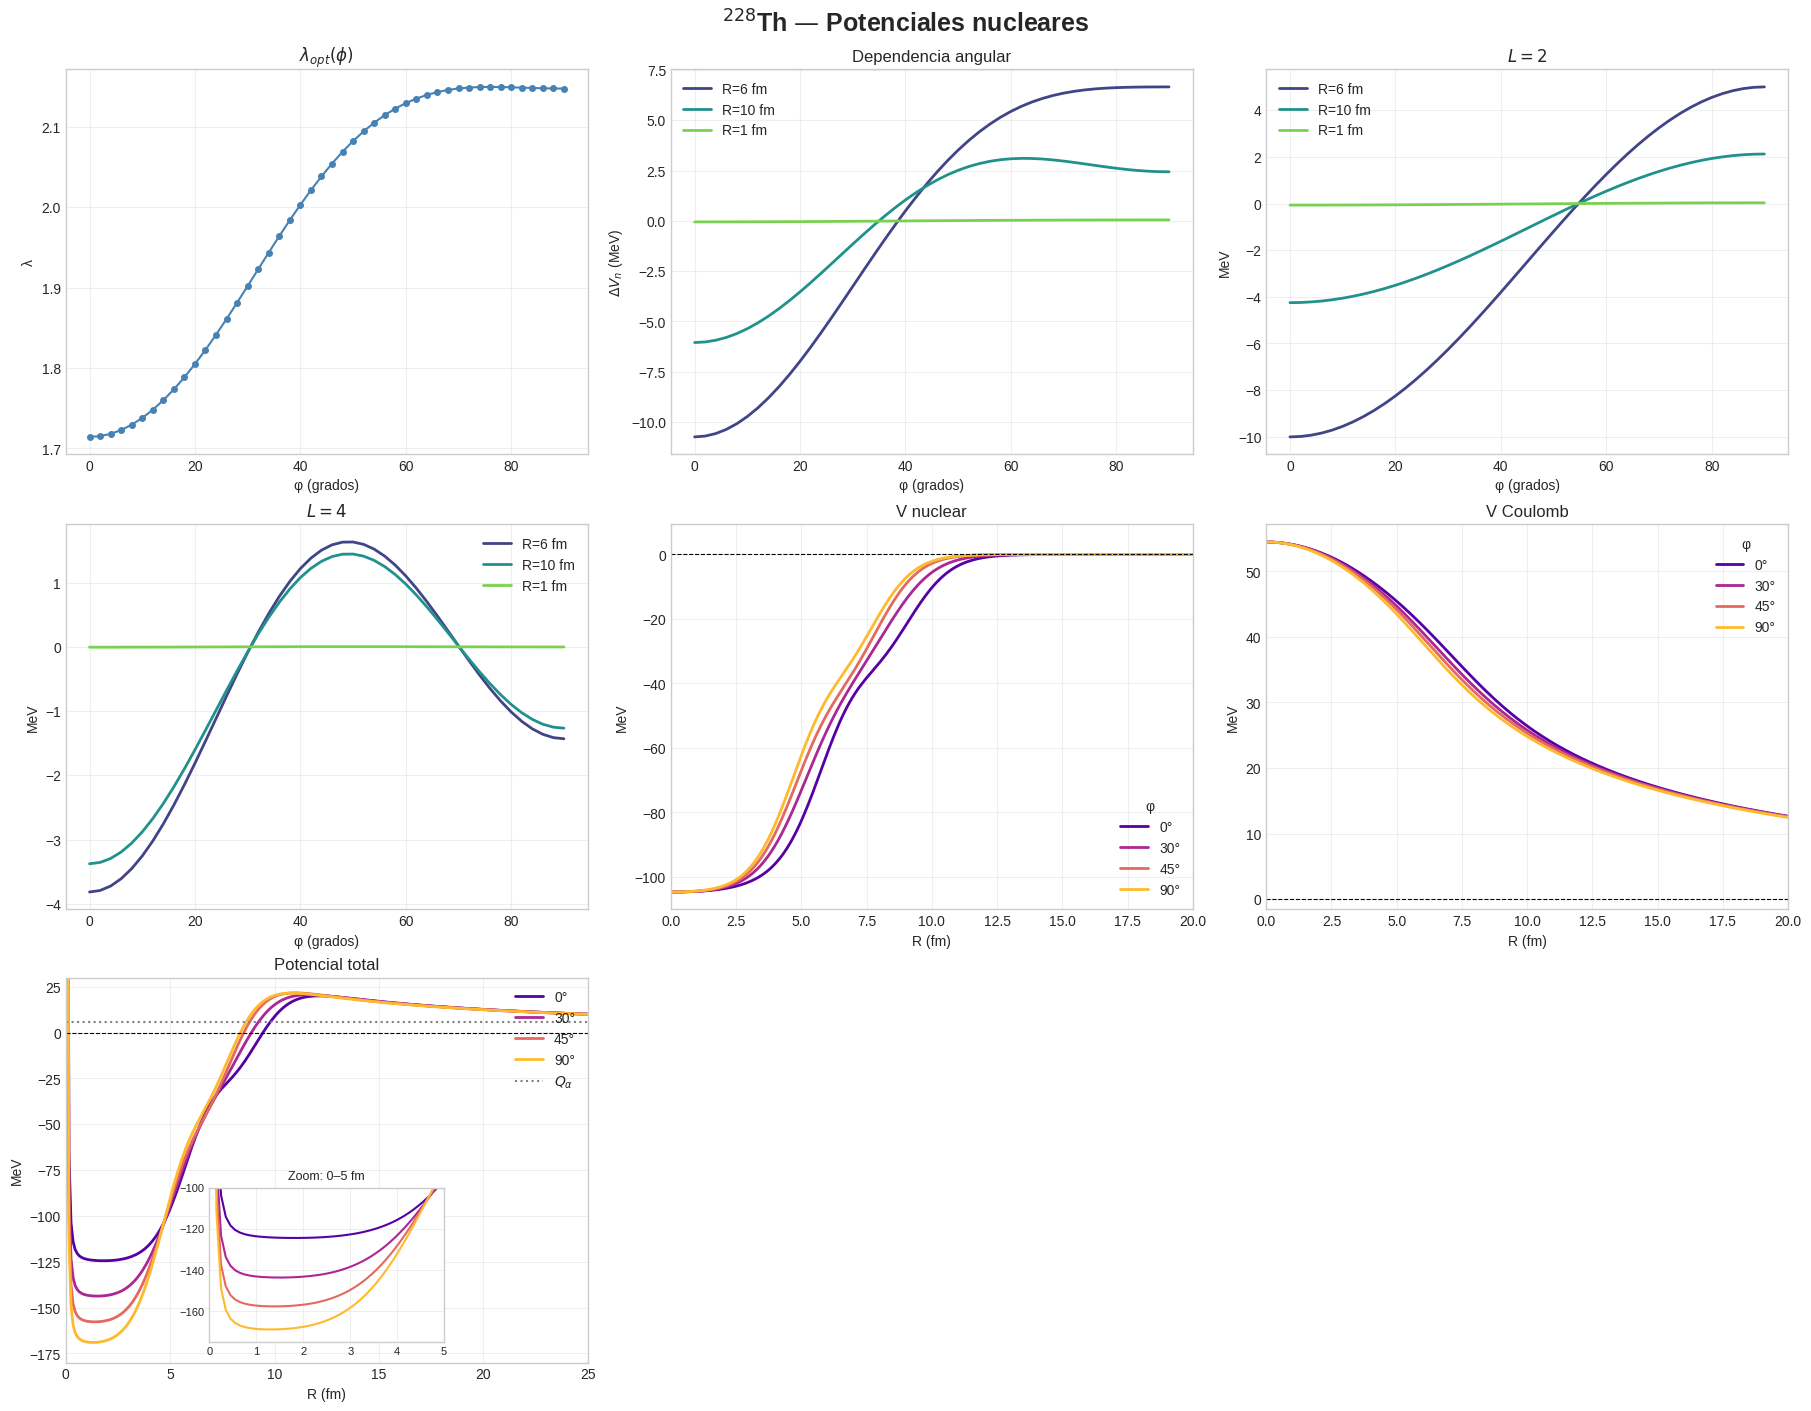

In [1]:
# Prove integral with decay 228-Th 
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad, simpson, dblquad
from scipy.interpolate import InterpolatedUnivariateSpline
from scipy.optimize import brentq
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
# ─── Constantes ───────────────────────────────────────────────────────────────
Z_alpha    = 2
Z_daugther = 88
e2         = 1.44
a_0        = 0.54
alpha      = 0.7024
beta       = 0.22
A_alpha    = 4
A_daugther = 224
x          = 7999 / 4
y          = 2134 / 2.5
R_0        = 1.07 * (A_daugther) ** (1 / 3)
beta2      = 0.164
beta4      = 0.112
J00        = -275
Q_alpha    = 5.520
hbarc      = 197.327
L          = 0
G          = 22
B          = (G - L + 1) * (np.pi / 2)
m_n        = 931.5
muc2       = (A_daugther * A_alpha) / (A_daugther + A_alpha) * m_n
zpb        = (muc2 * (beta) ** 2) / (2 * (hbarc) ** 2)

# ─── Armónicos esféricos y geometría de la hija ──────────────────────────────
def Y00(theta): return np.sqrt(1 / (4 * np.pi))
def Y20(theta): return (1 / 4) * np.sqrt(5 / np.pi) * (3 * np.cos(theta) ** 2 - 1)
def Y40(theta): return (3 / 16) * np.sqrt(1 / np.pi) * (35 * np.cos(theta) ** 4 - 30 * np.cos(theta) ** 2 + 3)

def R_f_theta(theta):
    return R_0 * (1 + beta2 * Y20(theta) + beta4 * Y40(theta))

def a_f_theta(theta):
    a_perp = a_0 * (1 + beta2 * Y20(theta) + beta4 * Y40(theta))
    gradR  = (R_0 / R_f_theta(theta)) * (
        -(3 / 2) * np.sqrt(5 / np.pi) * beta2 * np.cos(theta) * np.sin(theta)
        - (105 / 4) * np.sqrt(1 / np.pi) * beta4 * np.cos(theta) ** 3 * np.sin(theta)
        + (45  / 4) * np.sqrt(1 / np.pi) * beta4 * np.cos(theta) * np.sin(theta)
    )
    return a_perp * np.sqrt(1 + np.abs(gradR) ** 2)

# ─── Grillas ─────────────────────────────────────────────────────────────────
rmalla = np.linspace(0.01, 25, 500)
theta  = np.linspace(0, np.pi, 250)
r2, Theta = np.meshgrid(rmalla, theta, indexing='ij')   # (r, θ)

k = np.linspace(0.001, 25, 400)
R = np.linspace(0.05, 100, 1000)
phi = np.linspace(0, np.pi/2, 46)

# Densidad de Fermi (grilla r×θ) — calculada una sola vez
fermi_2D = 1.0 / (1.0 + np.exp((r2 - R_f_theta(Theta)) / a_f_theta(Theta)))

# ─── Funciones de Bessel esféricas ───────────────────────────────────────────
# Versión vectorizada (soporta arrays 2-D)
def j0_f(x): return np.sin(x) / x
def j2_f(x): return (3 / x**2 - 1) * np.sin(x) / x - 3 * np.cos(x) / x**2
def j4_f(x): return ((105 / x**5) - (45 / x**3) + (1 / x)) * np.sin(x) - ((105 / x**4) - (10 / x**2)) * np.cos(x)

# ─── Normalización densidad nuclear hija ─────────────────────────────────────
def rho2_integrand(theta, r):
    return (1 / (1 + np.exp((r - R_f_theta(theta)) / a_f_theta(theta)))) * r**2 * np.sin(theta)

I_rho2, _ = dblquad(rho2_integrand, 0.01, 15, 0, np.pi)
rho2_norm        = A_daugther / (2 * np.pi * I_rho2)
rho2_norm_coulomb = Z_daugther / (2 * np.pi * I_rho2)   # misma integral geométrica

# ─── Transformadas de Fourier de ρ₂ (vectorizadas) ──────────────────────────
# Grilla para la integración: r(eje 0), θ(eje 1), k(eje 2)
# Se construye una vez y se usa para los seis momentos (L=0,2,4 × nuclear/Coulomb)

r3   = rmalla[:, None, None]          # (r, 1, 1)
Th3  = theta[None, :, None]           # (1, θ, 1)
k3   = k[None, None, :]              # (1, 1, k)

fermi_3D = 1.0 / (1.0 + np.exp((r3 - R_f_theta(Th3)) / a_f_theta(Th3)))
sin_Th   = np.sin(Th3)

def fourier_rho2(norm, Ylm, jl, factor_4pi):
    # integrand shape: (r, θ, k)
    integrand = 2 * np.pi * norm * jl(r3 * k3) * Ylm(Th3) * r3**2 * sin_Th * fermi_3D
    int_r  = simpson(integrand, x=rmalla, axis=0)   # (θ, k)
    return simpson(int_r, x=theta, axis=0)           # (k,)

# jl evaluados sobre la grilla r×k
rho2_fn0 = fourier_rho2(rho2_norm,         Y00, j0_f, 1)
rho2_fn2 = fourier_rho2(rho2_norm,         Y20, j2_f, 1)
rho2_fn4 = fourier_rho2(rho2_norm,         Y40, j4_f, 1)

rho2_fc0 = fourier_rho2(rho2_norm_coulomb, Y00, j0_f, 1)
rho2_fc2 = fourier_rho2(rho2_norm_coulomb, Y20, j2_f, 1)
rho2_fc4 = fourier_rho2(rho2_norm_coulomb, Y40, j4_f, 1)

# ─── Transformadas de Fourier de ρ₁ (alfa — analíticas) ─────────────────────
I_r1, _         = quad(lambda r1: r1**2 * np.exp(-alpha * r1**2), 0, 15)
rho1_norm_c     = Z_alpha / (4 * np.pi * I_r1)
gauss_k         = np.exp(-k**2 / (4 * alpha))

rho1_fn = 0.4228 * (np.pi / alpha) ** 1.5 * gauss_k                       # nuclear
rho1_fc = rho1_norm_c * (np.pi / alpha) ** 1.5 * gauss_k                  # Coulomb

# ─── Potencial nuclear — integración en k vectorizada ────────────────────────
# V(R) = (2/π) · prefactor · ∫ ρ₁(k)·ρ₂L(k)·jL(kR)·k²·g(k) dk
# Grilla R×k:
Rm, km = np.meshgrid(R, k, indexing='ij')   # (R, k)
g_k    = x / (k**2 + 4**2) - y / (k**2 + 2.5**2)#+ (J00 / (4*np.pi))

def V_nuclear_L(rho1, rho2_fL, jLN, prefactor):
    integrand = prefactor * rho1[None, :] * rho2_fL[None, :] * jLN(Rm * km) * km**2 * (4 * np.pi * g_k[None, :])
    return (2 / np.pi) * simpson(integrand, x=k, axis=1)   # (R,)

V_NN0 = V_nuclear_L(rho1_fn, rho2_fn0, j0_f, 1 / np.sqrt(4 * np.pi))
V_NN2 = V_nuclear_L(rho1_fn, rho2_fn2, j2_f, np.sqrt(5 / (4 * np.pi)))
V_NN4 = V_nuclear_L(rho1_fn, rho2_fn4, j4_f, np.sqrt(9 / (4 * np.pi)))

# ─── Potencial Coulomb — integración en k vectorizada ────────────────────────
def V_coulomb_L(rho1, rho2_fL, jLN, prefactor):
    integrand = prefactor * rho1[None, :] * rho2_fL[None, :] * jLN(Rm * km)
    return (2 * e2 / np.pi) * simpson(integrand, x=k, axis=1)

V_C0 = V_coulomb_L(rho1_fc, rho2_fc0, j0_f, 4 * np.pi / np.sqrt(4 * np.pi))
V_C2 = V_coulomb_L(rho1_fc, rho2_fc2, j2_f, 4 * np.pi * np.sqrt(5  / (4 * np.pi)))
V_C4 = V_coulomb_L(rho1_fc, rho2_fc4, j4_f, 4 * np.pi * np.sqrt(9  / (4 * np.pi)))

# ─── Polinomios de Legendre y ensamble final ──────────────────────────────────
def P2(phi): return 0.5 * (3 * np.cos(phi)**2 - 1)
def P4(phi): return (1 / 8) * (35 * np.cos(phi)**4 - 30 * np.cos(phi)**2 + 3)

# Potencial nuclear total: (R, φ)
V_Nuclear = (
    V_NN0[:, None]
    + V_NN2[:, None] * P2(phi)[None, :]
    + V_NN4[:, None] * P4(phi)[None, :]
)

# Potencial Coulomb total: (R, φ)
V_Coulomb = (
    V_C0[:, None]
    + V_C2[:, None] * P2(phi)[None, :]
    + V_C4[:, None] * P4(phi)[None, :]
)

# ─── Potencial centrífugo ─────────────────────────────────────────────────────
V_L = (hbarc**2 / (2 * muc2)) * ((L + 0.5)**2 / R**2)

def accion_phi_lam(lam, phi_idx):
    V_total = lam * V_Nuclear[:, phi_idx] + V_Coulomb[:, phi_idx] + V_L
    s = InterpolatedUnivariateSpline(R, Q_alpha - V_total, k=3)
    roots = s.roots()
    if len(roots) < 2:
        return None
    r1, r2 = roots[0], roots[1]
    f = lambda r: np.sqrt(np.abs((2 * muc2 / hbarc**2) * s(r)))
    return quad(f, r1, r2, limit=200)[0]

lam_opt_vs_phi = []

for i, ph in enumerate(phi):
    try:
        # brentq encuentra el lambda donde S(λ) - B = 0
        lam_opt_i = brentq(
            lambda lam: accion_phi_lam(lam, i) - B,
            a=0.5, b=3.0,
            xtol=1e-4
        )
        lam_opt_vs_phi.append((ph, lam_opt_i))
        print(f"φ = {np.degrees(ph):6.1f}°  →  λ = {lam_opt_i:.4f}")
    except (ValueError, TypeError):
        lam_opt_vs_phi.append((ph, None))
        print(f"φ = {np.degrees(ph):6.1f}°  →  sin solución")


phi_arr = np.array([p for p, l in lam_opt_vs_phi if l is not None])
lam_arr = np.array([l for p, l in lam_opt_vs_phi if l is not None])
print('lambda promedio = ',np.around(np.sum(lam_arr)/46,2))

plt.style.use('seaborn-v0_8-whitegrid')

idx1 = np.argmin(np.abs(R - 6))
idx2 = np.argmin(np.abs(R - 10))
idx3 = np.argmin(np.abs(R - 1))

phi_plot  = [0, np.pi/6, np.pi/4, np.pi/2]
phi_lbls  = ['0°', '30°', '45°', '90°']
phi_idxs  = [np.argmin(np.abs(phi - p)) for p in phi_plot]

colors_ph = plt.cm.plasma(np.linspace(0.15, 0.85, len(phi_plot)))
colors_R  = plt.cm.viridis(np.linspace(0.2, 0.8, 3))

fig, axs = plt.subplots(3, 3, figsize=(18, 14), constrained_layout=True)
fig.suptitle(r"$^{228}$Th — Potenciales nucleares", fontsize=18, fontweight='bold')

# ─────────────────────────────────────────────
# [0,0] λ vs φ
axs[0,0].plot(np.degrees(phi_arr), lam_arr, '-o', ms=4, lw=1.5, color='steelblue')
axs[0,0].set(xlabel="φ (grados)", ylabel="λ", title=r"$\lambda_{opt}(\phi)$")
axs[0,0].grid(alpha=0.3)

# ─────────────────────────────────────────────
# [0,1] V_N vs φ (centrado)
for idx, lbl, col in zip([idx1, idx2, idx3], ['6 fm', '10 fm', '1 fm'], colors_R):
    V = V_Nuclear[idx,:]
    axs[0,1].plot(np.degrees(phi), V - np.mean(V), lw=2, label=f'R={lbl}', color=col)

axs[0,1].set(xlabel="φ (grados)", ylabel=r"$\Delta V_n$ (MeV)", title="Dependencia angular")
axs[0,1].legend(frameon=False)
axs[0,1].grid(alpha=0.3)

# ─────────────────────────────────────────────
# [0,2] L=2
for idx, lbl, col in zip([idx1, idx2, idx3], ['6 fm', '10 fm', '1 fm'], colors_R):
    axs[0,2].plot(np.degrees(phi), V_NN2[idx]*P2(phi), lw=2, label=f'R={lbl}', color=col)

axs[0,2].set(xlabel="φ (grados)", ylabel="MeV", title=r"$L=2$")
axs[0,2].legend(frameon=False)
axs[0,2].grid(alpha=0.3)

# ─────────────────────────────────────────────
# [1,0] L=4
for idx, lbl, col in zip([idx1, idx2, idx3], ['6 fm', '10 fm', '1 fm'], colors_R):
    axs[1,0].plot(np.degrees(phi), V_NN4[idx]*P4(phi), lw=2, label=f'R={lbl}', color=col)

axs[1,0].set(xlabel="φ (grados)", ylabel="MeV", title=r"$L=4$")
axs[1,0].legend(frameon=False)
axs[1,0].grid(alpha=0.3)

# ─────────────────────────────────────────────
# [1,1] V_N vs R
for pidx, lbl, col in zip(phi_idxs, phi_lbls, colors_ph):
    axs[1,1].plot(R, V_Nuclear[:, pidx], lw=2, label=lbl, color=col)

axs[1,1].set(xlabel="R (fm)", ylabel="MeV", title="V nuclear")
axs[1,1].axhline(0, color='black', lw=0.8, ls='--')
axs[1,1].set_xlim(0, 20)
axs[1,1].legend(title="φ")
axs[1,1].grid(alpha=0.3)

# ─────────────────────────────────────────────
# [1,2] V_C
for pidx, lbl, col in zip(phi_idxs, phi_lbls, colors_ph):
    axs[1,2].plot(R, V_Coulomb[:, pidx], lw=2, label=lbl, color=col)

axs[1,2].set(xlabel="R (fm)", ylabel="MeV", title="V Coulomb")
axs[1,2].axhline(0, color='black', lw=0.8, ls='--')
axs[1,2].set_xlim(0, 20)
axs[1,2].legend(title="φ")
axs[1,2].grid(alpha=0.3)

# ─────────────────────────────────────────────
# [2,0] V total
lam_interp = np.interp(phi, phi_arr, lam_arr)
for pidx, lbl, col in zip(phi_idxs, phi_lbls, colors_ph):
    V_tot = lam_interp[pidx]*V_Nuclear[:,pidx] + V_Coulomb[:,pidx] + V_L
    axs[2,0].plot(R, V_tot, lw=2, label=lbl, color=col)
axs[2,0].axhline(Q_alpha, color='gray', lw=1.5, ls=':', label=r"$Q_\alpha$")
axs[2,0].axhline(0, color='black', lw=0.8, ls='--')
axs[2,0].set(xlabel="R (fm)", ylabel="MeV", title="Potencial total")
axs[2,0].set_xlim(0, 25)
axs[2,0].set_ylim(-180, 30)
axs[2,0].legend(loc='upper right')
axs[2,0].grid(alpha=0.3)

# ─────────── INSET: zoom 0 a 5 fm (abajo a la derecha) ───────────
axins = inset_axes(axs[2,0], width="45%", height="40%",
                   loc='lower center', borderpad=1.5)
for pidx, lbl, col in zip(phi_idxs, phi_lbls, colors_ph):
    V_tot = lam_interp[pidx]*V_Nuclear[:,pidx] + V_Coulomb[:,pidx] + V_L
    axins.plot(R, V_tot, lw=1.5, color=col)
axins.axhline(Q_alpha, color='gray', lw=1, ls=':')
axins.axhline(0, color='black', lw=0.6, ls='--')
axins.set_xlim(0, 5)
axins.set_ylim(-175, -100)
axins.set_title('Zoom: 0–5 fm', fontsize=9)
axins.tick_params(labelsize=8)
axins.grid(alpha=0.3)


axs[2,1].axis('off')
axs[2,2].axis('off')
plt.show()


φ =    0.0°  →  λ = 1.6657
φ =    2.0°  →  λ = 1.6667
φ =    4.0°  →  λ = 1.6697
φ =    6.0°  →  λ = 1.6746
φ =    8.0°  →  λ = 1.6814
φ =   10.0°  →  λ = 1.6901
φ =   12.0°  →  λ = 1.7007
φ =   14.0°  →  λ = 1.7130
φ =   16.0°  →  λ = 1.7271
φ =   18.0°  →  λ = 1.7429
φ =   20.0°  →  λ = 1.7601
φ =   22.0°  →  λ = 1.7788
φ =   24.0°  →  λ = 1.7987
φ =   26.0°  →  λ = 1.8196
φ =   28.0°  →  λ = 1.8414
φ =   30.0°  →  λ = 1.8637
φ =   32.0°  →  λ = 1.8864
φ =   34.0°  →  λ = 1.9092
φ =   36.0°  →  λ = 1.9319
φ =   38.0°  →  λ = 1.9541
φ =   40.0°  →  λ = 1.9758
φ =   42.0°  →  λ = 1.9967
φ =   44.0°  →  λ = 2.0166
φ =   46.0°  →  λ = 2.0355
φ =   48.0°  →  λ = 2.0533
φ =   50.0°  →  λ = 2.0698
φ =   52.0°  →  λ = 2.0851
φ =   54.0°  →  λ = 2.0991
φ =   56.0°  →  λ = 2.1118
φ =   58.0°  →  λ = 2.1231
φ =   60.0°  →  λ = 2.1332
φ =   62.0°  →  λ = 2.1420
φ =   64.0°  →  λ = 2.1496
φ =   66.0°  →  λ = 2.1561
φ =   68.0°  →  λ = 2.1616
φ =   70.0°  →  λ = 2.1662
φ =   72.0°  →  λ = 2.1699
φ

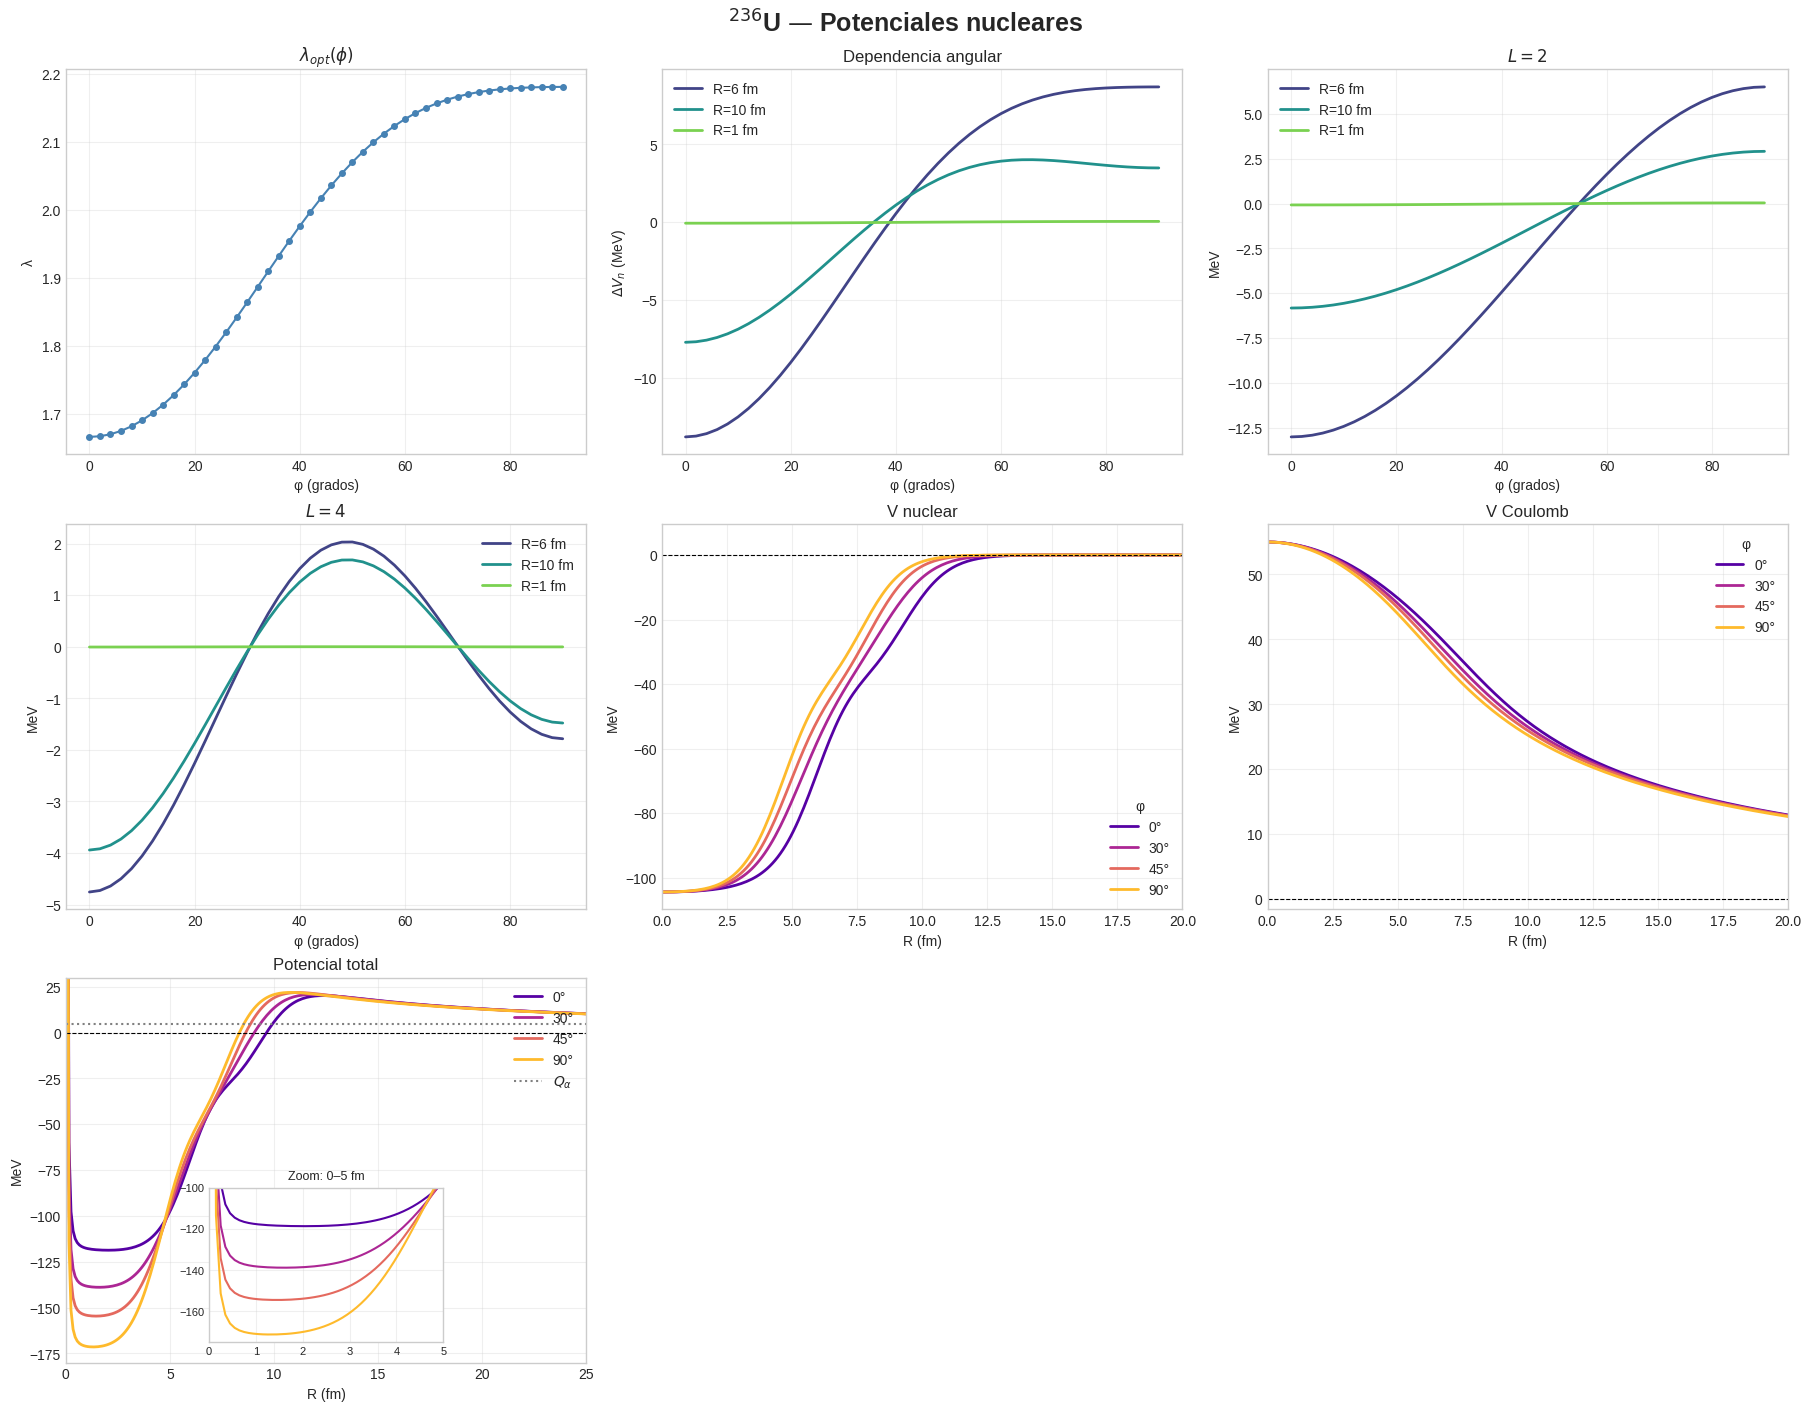

In [1]:
# Prove integral with decay 236-U 
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad, simpson, dblquad
from scipy.interpolate import InterpolatedUnivariateSpline
from scipy.optimize import brentq
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
# ─── Constantes ───────────────────────────────────────────────────────────────
Z_alpha    = 2
Z_daugther = 90
e2         = 1.44
a_0        = 0.54
alpha      = 0.7024
beta       = 0.22
A_alpha    = 4
A_daugther = 232
x          = 7999 / 4
y          = 2134 / 2.5
R_0        = 1.07 * (A_daugther) ** (1 / 3)
beta2      = 0.207
beta4      = 0.108
J00        = -275
Q_alpha    = 4.57
hbarc      = 197.327
L          = 0
G          = 22
B          = (G - L + 1) * (np.pi / 2)
m_n        = 931.5
muc2       = (A_daugther * A_alpha) / (A_daugther + A_alpha) * m_n
zpb        = (muc2 * (beta) ** 2) / (2 * (hbarc) ** 2)

# ─── Armónicos esféricos y geometría de la hija ──────────────────────────────
def Y00(theta): return np.sqrt(1 / (4 * np.pi))
def Y20(theta): return (1 / 4) * np.sqrt(5 / np.pi) * (3 * np.cos(theta) ** 2 - 1)
def Y40(theta): return (3 / 16) * np.sqrt(1 / np.pi) * (35 * np.cos(theta) ** 4 - 30 * np.cos(theta) ** 2 + 3)

def R_f_theta(theta):
    return R_0 * (1 + beta2 * Y20(theta) + beta4 * Y40(theta))

def a_f_theta(theta):
    a_perp = a_0 * (1 + beta2 * Y20(theta) + beta4 * Y40(theta))
    gradR  = (R_0 / R_f_theta(theta)) * (
        -(3 / 2) * np.sqrt(5 / np.pi) * beta2 * np.cos(theta) * np.sin(theta)
        - (105 / 4) * np.sqrt(1 / np.pi) * beta4 * np.cos(theta) ** 3 * np.sin(theta)
        + (45  / 4) * np.sqrt(1 / np.pi) * beta4 * np.cos(theta) * np.sin(theta)
    )
    return a_perp * np.sqrt(1 + np.abs(gradR) ** 2)

# ─── Grillas ─────────────────────────────────────────────────────────────────
rmalla = np.linspace(0.01, 25, 500)
theta  = np.linspace(0, np.pi, 250)
r2, Theta = np.meshgrid(rmalla, theta, indexing='ij')   # (r, θ)

k = np.linspace(0.001, 25, 400)
R = np.linspace(0.05, 100, 1000)
phi = np.linspace(0, np.pi/2, 46)

# Densidad de Fermi (grilla r×θ) — calculada una sola vez
fermi_2D = 1.0 / (1.0 + np.exp((r2 - R_f_theta(Theta)) / a_f_theta(Theta)))

# ─── Funciones de Bessel esféricas ───────────────────────────────────────────
# Versión vectorizada (soporta arrays 2-D)
def j0_f(x): return np.sin(x) / x
def j2_f(x): return (3 / x**2 - 1) * np.sin(x) / x - 3 * np.cos(x) / x**2
def j4_f(x): return ((105 / x**5) - (45 / x**3) + (1 / x)) * np.sin(x) - ((105 / x**4) - (10 / x**2)) * np.cos(x)

# ─── Normalización densidad nuclear hija ─────────────────────────────────────
def rho2_integrand(theta, r):
    return (1 / (1 + np.exp((r - R_f_theta(theta)) / a_f_theta(theta)))) * r**2 * np.sin(theta)

I_rho2, _ = dblquad(rho2_integrand, 0.01, 15, 0, np.pi)
rho2_norm        = A_daugther / (2 * np.pi * I_rho2)
rho2_norm_coulomb = Z_daugther / (2 * np.pi * I_rho2)   # misma integral geométrica

# ─── Transformadas de Fourier de ρ₂ (vectorizadas) ──────────────────────────
# Grilla para la integración: r(eje 0), θ(eje 1), k(eje 2)
# Se construye una vez y se usa para los seis momentos (L=0,2,4 × nuclear/Coulomb)

r3   = rmalla[:, None, None]          # (r, 1, 1)
Th3  = theta[None, :, None]           # (1, θ, 1)
k3   = k[None, None, :]              # (1, 1, k)

fermi_3D = 1.0 / (1.0 + np.exp((r3 - R_f_theta(Th3)) / a_f_theta(Th3)))
sin_Th   = np.sin(Th3)

def fourier_rho2(norm, Ylm, jl, factor_4pi):
    # integrand shape: (r, θ, k)
    integrand = 2 * np.pi * norm * jl(r3 * k3) * Ylm(Th3) * r3**2 * sin_Th * fermi_3D
    int_r  = simpson(integrand, x=rmalla, axis=0)   # (θ, k)
    return simpson(int_r, x=theta, axis=0)           # (k,)

# jl evaluados sobre la grilla r×k
rho2_fn0 = fourier_rho2(rho2_norm,         Y00, j0_f, 1)
rho2_fn2 = fourier_rho2(rho2_norm,         Y20, j2_f, 1)
rho2_fn4 = fourier_rho2(rho2_norm,         Y40, j4_f, 1)

rho2_fc0 = fourier_rho2(rho2_norm_coulomb, Y00, j0_f, 1)
rho2_fc2 = fourier_rho2(rho2_norm_coulomb, Y20, j2_f, 1)
rho2_fc4 = fourier_rho2(rho2_norm_coulomb, Y40, j4_f, 1)

# ─── Transformadas de Fourier de ρ₁ (alfa — analíticas) ─────────────────────
I_r1, _         = quad(lambda r1: r1**2 * np.exp(-alpha * r1**2), 0, 15)
rho1_norm_c     = Z_alpha / (4 * np.pi * I_r1)
gauss_k         = np.exp(-k**2 / (4 * alpha))

rho1_fn = 0.4228 * (np.pi / alpha) ** 1.5 * gauss_k                       # nuclear
rho1_fc = rho1_norm_c * (np.pi / alpha) ** 1.5 * gauss_k                  # Coulomb

# ─── Potencial nuclear — integración en k vectorizada ────────────────────────
# V(R) = (2/π) · prefactor · ∫ ρ₁(k)·ρ₂L(k)·jL(kR)·k²·g(k) dk
# Grilla R×k:
Rm, km = np.meshgrid(R, k, indexing='ij')   # (R, k)
g_k    = x / (k**2 + 4**2) - y / (k**2 + 2.5**2)#  (J00 / (4 * np.pi))

def V_nuclear_L(rho1, rho2_fL, jLN, prefactor):
    integrand = prefactor * rho1[None, :] * rho2_fL[None, :] * jLN(Rm * km) * km**2 * (4 * np.pi * g_k[None, :])
    return (2 / np.pi) * simpson(integrand, x=k, axis=1)   # (R,)

V_NN0 = V_nuclear_L(rho1_fn, rho2_fn0, j0_f, 1 / np.sqrt(4 * np.pi))
V_NN2 = V_nuclear_L(rho1_fn, rho2_fn2, j2_f, np.sqrt(5 / (4 * np.pi)))
V_NN4 = V_nuclear_L(rho1_fn, rho2_fn4, j4_f, np.sqrt(9 / (4 * np.pi)))

# ─── Potencial Coulomb — integración en k vectorizada ────────────────────────
def V_coulomb_L(rho1, rho2_fL, jLN, prefactor):
    integrand = prefactor * rho1[None, :] * rho2_fL[None, :] * jLN(Rm * km)
    return (2 * e2 / np.pi) * simpson(integrand, x=k, axis=1)

V_C0 = V_coulomb_L(rho1_fc, rho2_fc0, j0_f, 4 * np.pi / np.sqrt(4 * np.pi))
V_C2 = V_coulomb_L(rho1_fc, rho2_fc2, j2_f, 4 * np.pi * np.sqrt(5  / (4 * np.pi)))
V_C4 = V_coulomb_L(rho1_fc, rho2_fc4, j4_f, 4 * np.pi * np.sqrt(9  / (4 * np.pi)))

# ─── Polinomios de Legendre y ensamble final ──────────────────────────────────
def P2(phi): return 0.5 * (3 * np.cos(phi)**2 - 1)
def P4(phi): return (1 / 8) * (35 * np.cos(phi)**4 - 30 * np.cos(phi)**2 + 3)

# Potencial nuclear total: (R, φ)
V_Nuclear = (
    V_NN0[:, None]
    + V_NN2[:, None] * P2(phi)[None, :]
    + V_NN4[:, None] * P4(phi)[None, :]
)

# Potencial Coulomb total: (R, φ)
V_Coulomb = (
    V_C0[:, None]
    + V_C2[:, None] * P2(phi)[None, :]
    + V_C4[:, None] * P4(phi)[None, :]
)

# ─── Potencial centrífugo ─────────────────────────────────────────────────────
V_L = (hbarc**2 / (2 * muc2)) * ((L + 0.5)**2 / R**2)

def accion_phi_lam(lam, phi_idx):
    V_total = lam * V_Nuclear[:, phi_idx] + V_Coulomb[:, phi_idx] + V_L
    s = InterpolatedUnivariateSpline(R, Q_alpha - V_total, k=3)
    roots = s.roots()
    if len(roots) < 2:
        return None
    r1, r2 = roots[0], roots[1]
    f = lambda r: np.sqrt(np.abs((2 * muc2 / hbarc**2) * s(r)))
    return quad(f, r1, r2, limit=200)[0]

lam_opt_vs_phi = []

for i, ph in enumerate(phi):
    try:
        # brentq encuentra el lambda donde S(λ) - B = 0
        lam_opt_i = brentq(
            lambda lam: accion_phi_lam(lam, i) - B,
            a=0.5, b=3.0,
            xtol=1e-4
        )
        lam_opt_vs_phi.append((ph, lam_opt_i))
        print(f"φ = {np.degrees(ph):6.1f}°  →  λ = {lam_opt_i:.4f}")
    except (ValueError, TypeError):
        lam_opt_vs_phi.append((ph, None))
        print(f"φ = {np.degrees(ph):6.1f}°  →  sin solución")


phi_arr = np.array([p for p, l in lam_opt_vs_phi if l is not None])
lam_arr = np.array([l for p, l in lam_opt_vs_phi if l is not None])
print('lambda promedio = ',np.around(np.sum(lam_arr)/45,2))

plt.style.use('seaborn-v0_8-whitegrid')

idx1 = np.argmin(np.abs(R - 6))
idx2 = np.argmin(np.abs(R - 10))
idx3 = np.argmin(np.abs(R - 1))

phi_plot  = [0, np.pi/6, np.pi/4, np.pi/2]
phi_lbls  = ['0°', '30°', '45°', '90°']
phi_idxs  = [np.argmin(np.abs(phi - p)) for p in phi_plot]

colors_ph = plt.cm.plasma(np.linspace(0.15, 0.85, len(phi_plot)))
colors_R  = plt.cm.viridis(np.linspace(0.2, 0.8, 3))

fig, axs = plt.subplots(3, 3, figsize=(18, 14), constrained_layout=True)
fig.suptitle(r"$^{236}$U — Potenciales nucleares", fontsize=18, fontweight='bold')

# ─────────────────────────────────────────────
# [0,0] λ vs φ
axs[0,0].plot(np.degrees(phi_arr), lam_arr, '-o', ms=4, lw=1.5, color='steelblue')
axs[0,0].set(xlabel="φ (grados)", ylabel="λ", title=r"$\lambda_{opt}(\phi)$")
axs[0,0].grid(alpha=0.3)

# ─────────────────────────────────────────────
# [0,1] V_N vs φ (centrado)
for idx, lbl, col in zip([idx1, idx2, idx3], ['6 fm', '10 fm', '1 fm'], colors_R):
    V = V_Nuclear[idx,:]
    axs[0,1].plot(np.degrees(phi), V - np.mean(V), lw=2, label=f'R={lbl}', color=col)

axs[0,1].set(xlabel="φ (grados)", ylabel=r"$\Delta V_n$ (MeV)", title="Dependencia angular")
axs[0,1].legend(frameon=False)
axs[0,1].grid(alpha=0.3)

# ─────────────────────────────────────────────
# [0,2] L=2
for idx, lbl, col in zip([idx1, idx2, idx3], ['6 fm', '10 fm', '1 fm'], colors_R):
    axs[0,2].plot(np.degrees(phi), V_NN2[idx]*P2(phi), lw=2, label=f'R={lbl}', color=col)

axs[0,2].set(xlabel="φ (grados)", ylabel="MeV", title=r"$L=2$")
axs[0,2].legend(frameon=False)
axs[0,2].grid(alpha=0.3)

# ─────────────────────────────────────────────
# [1,0] L=4
for idx, lbl, col in zip([idx1, idx2, idx3], ['6 fm', '10 fm', '1 fm'], colors_R):
    axs[1,0].plot(np.degrees(phi), V_NN4[idx]*P4(phi), lw=2, label=f'R={lbl}', color=col)

axs[1,0].set(xlabel="φ (grados)", ylabel="MeV", title=r"$L=4$")
axs[1,0].legend(frameon=False)
axs[1,0].grid(alpha=0.3)

# ─────────────────────────────────────────────
# [1,1] V_N vs R
for pidx, lbl, col in zip(phi_idxs, phi_lbls, colors_ph):
    axs[1,1].plot(R, V_Nuclear[:, pidx], lw=2, label=lbl, color=col)

axs[1,1].set(xlabel="R (fm)", ylabel="MeV", title="V nuclear")
axs[1,1].axhline(0, color='black', lw=0.8, ls='--')
axs[1,1].set_xlim(0, 20)
axs[1,1].legend(title="φ")
axs[1,1].grid(alpha=0.3)

# ─────────────────────────────────────────────
# [1,2] V_C
for pidx, lbl, col in zip(phi_idxs, phi_lbls, colors_ph):
    axs[1,2].plot(R, V_Coulomb[:, pidx], lw=2, label=lbl, color=col)

axs[1,2].set(xlabel="R (fm)", ylabel="MeV", title="V Coulomb")
axs[1,2].axhline(0, color='black', lw=0.8, ls='--')
axs[1,2].set_xlim(0, 20)
axs[1,2].legend(title="φ")
axs[1,2].grid(alpha=0.3)

# ─────────────────────────────────────────────
# [2,0] V total
lam_interp = np.interp(phi, phi_arr, lam_arr)
for pidx, lbl, col in zip(phi_idxs, phi_lbls, colors_ph):
    V_tot = lam_interp[pidx]*V_Nuclear[:,pidx] + V_Coulomb[:,pidx] + V_L
    axs[2,0].plot(R, V_tot, lw=2, label=lbl, color=col)
axs[2,0].axhline(Q_alpha, color='gray', lw=1.5, ls=':', label=r"$Q_\alpha$")
axs[2,0].axhline(0, color='black', lw=0.8, ls='--')
axs[2,0].set(xlabel="R (fm)", ylabel="MeV", title="Potencial total")
axs[2,0].set_xlim(0, 25)
axs[2,0].set_ylim(-180, 30)
axs[2,0].legend(loc='upper right')
axs[2,0].grid(alpha=0.3)

# ─────────── INSET: zoom 0 a 5 fm (abajo a la derecha) ───────────
axins = inset_axes(axs[2,0], width="45%", height="40%",
                   loc='lower center', borderpad=1.5)
for pidx, lbl, col in zip(phi_idxs, phi_lbls, colors_ph):
    V_tot = lam_interp[pidx]*V_Nuclear[:,pidx] + V_Coulomb[:,pidx] + V_L
    axins.plot(R, V_tot, lw=1.5, color=col)
axins.axhline(Q_alpha, color='gray', lw=1, ls=':')
axins.axhline(0, color='black', lw=0.6, ls='--')
axins.set_xlim(0, 5)
axins.set_ylim(-175, -100)
axins.set_title('Zoom: 0–5 fm', fontsize=9)
axins.tick_params(labelsize=8)
axins.grid(alpha=0.3)


axs[2,1].axis('off')
axs[2,2].axis('off')
plt.show()


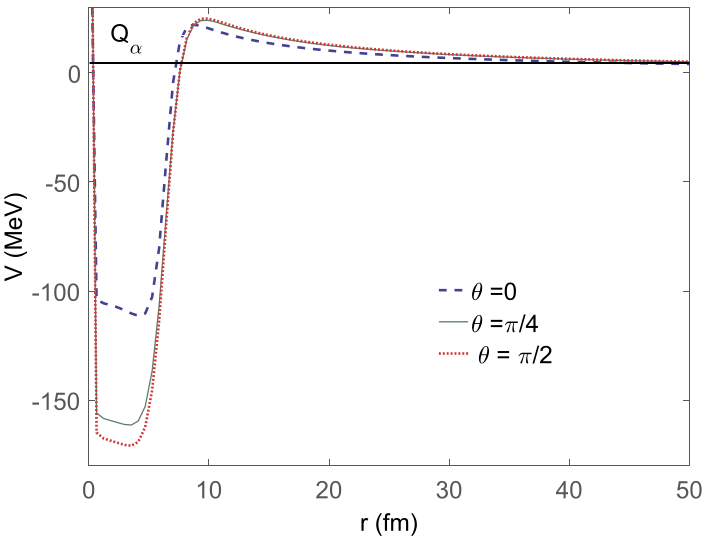!

φ =    0.0° → λ = 2.2953
φ =    2.0° → λ = 2.2951
φ =    4.0° → λ = 2.2943
φ =    6.0° → λ = 2.2929
φ =    8.0° → λ = 2.2911
φ =   10.0° → λ = 2.2887
φ =   12.0° → λ = 2.2858
φ =   14.0° → λ = 2.2823
φ =   16.0° → λ = 2.2784
φ =   18.0° → λ = 2.2740
φ =   20.0° → λ = 2.2692
φ =   22.0° → λ = 2.2639
φ =   24.0° → λ = 2.2581
φ =   26.0° → λ = 2.2520
φ =   28.0° → λ = 2.2454
φ =   30.0° → λ = 2.2385
φ =   32.0° → λ = 2.2313
φ =   34.0° → λ = 2.2237
φ =   36.0° → λ = 2.2159
φ =   38.0° → λ = 2.2078
φ =   40.0° → λ = 2.1996
φ =   42.0° → λ = 2.1911
φ =   44.0° → λ = 2.1825
φ =   46.0° → λ = 2.1739
φ =   48.0° → λ = 2.1652
φ =   50.0° → λ = 2.1565
φ =   52.0° → λ = 2.1478
φ =   54.0° → λ = 2.1393
φ =   56.0° → λ = 2.1308
φ =   58.0° → λ = 2.1226
φ =   60.0° → λ = 2.1146
φ =   62.0° → λ = 2.1068
φ =   64.0° → λ = 2.0994
φ =   66.0° → λ = 2.0923
φ =   68.0° → λ = 2.0857
φ =   70.0° → λ = 2.0794
φ =   72.0° → λ = 2.0737
φ =   74.0° → λ = 2.0684
φ =   76.0° → λ = 2.0637
φ =   78.0° → λ = 2.0596


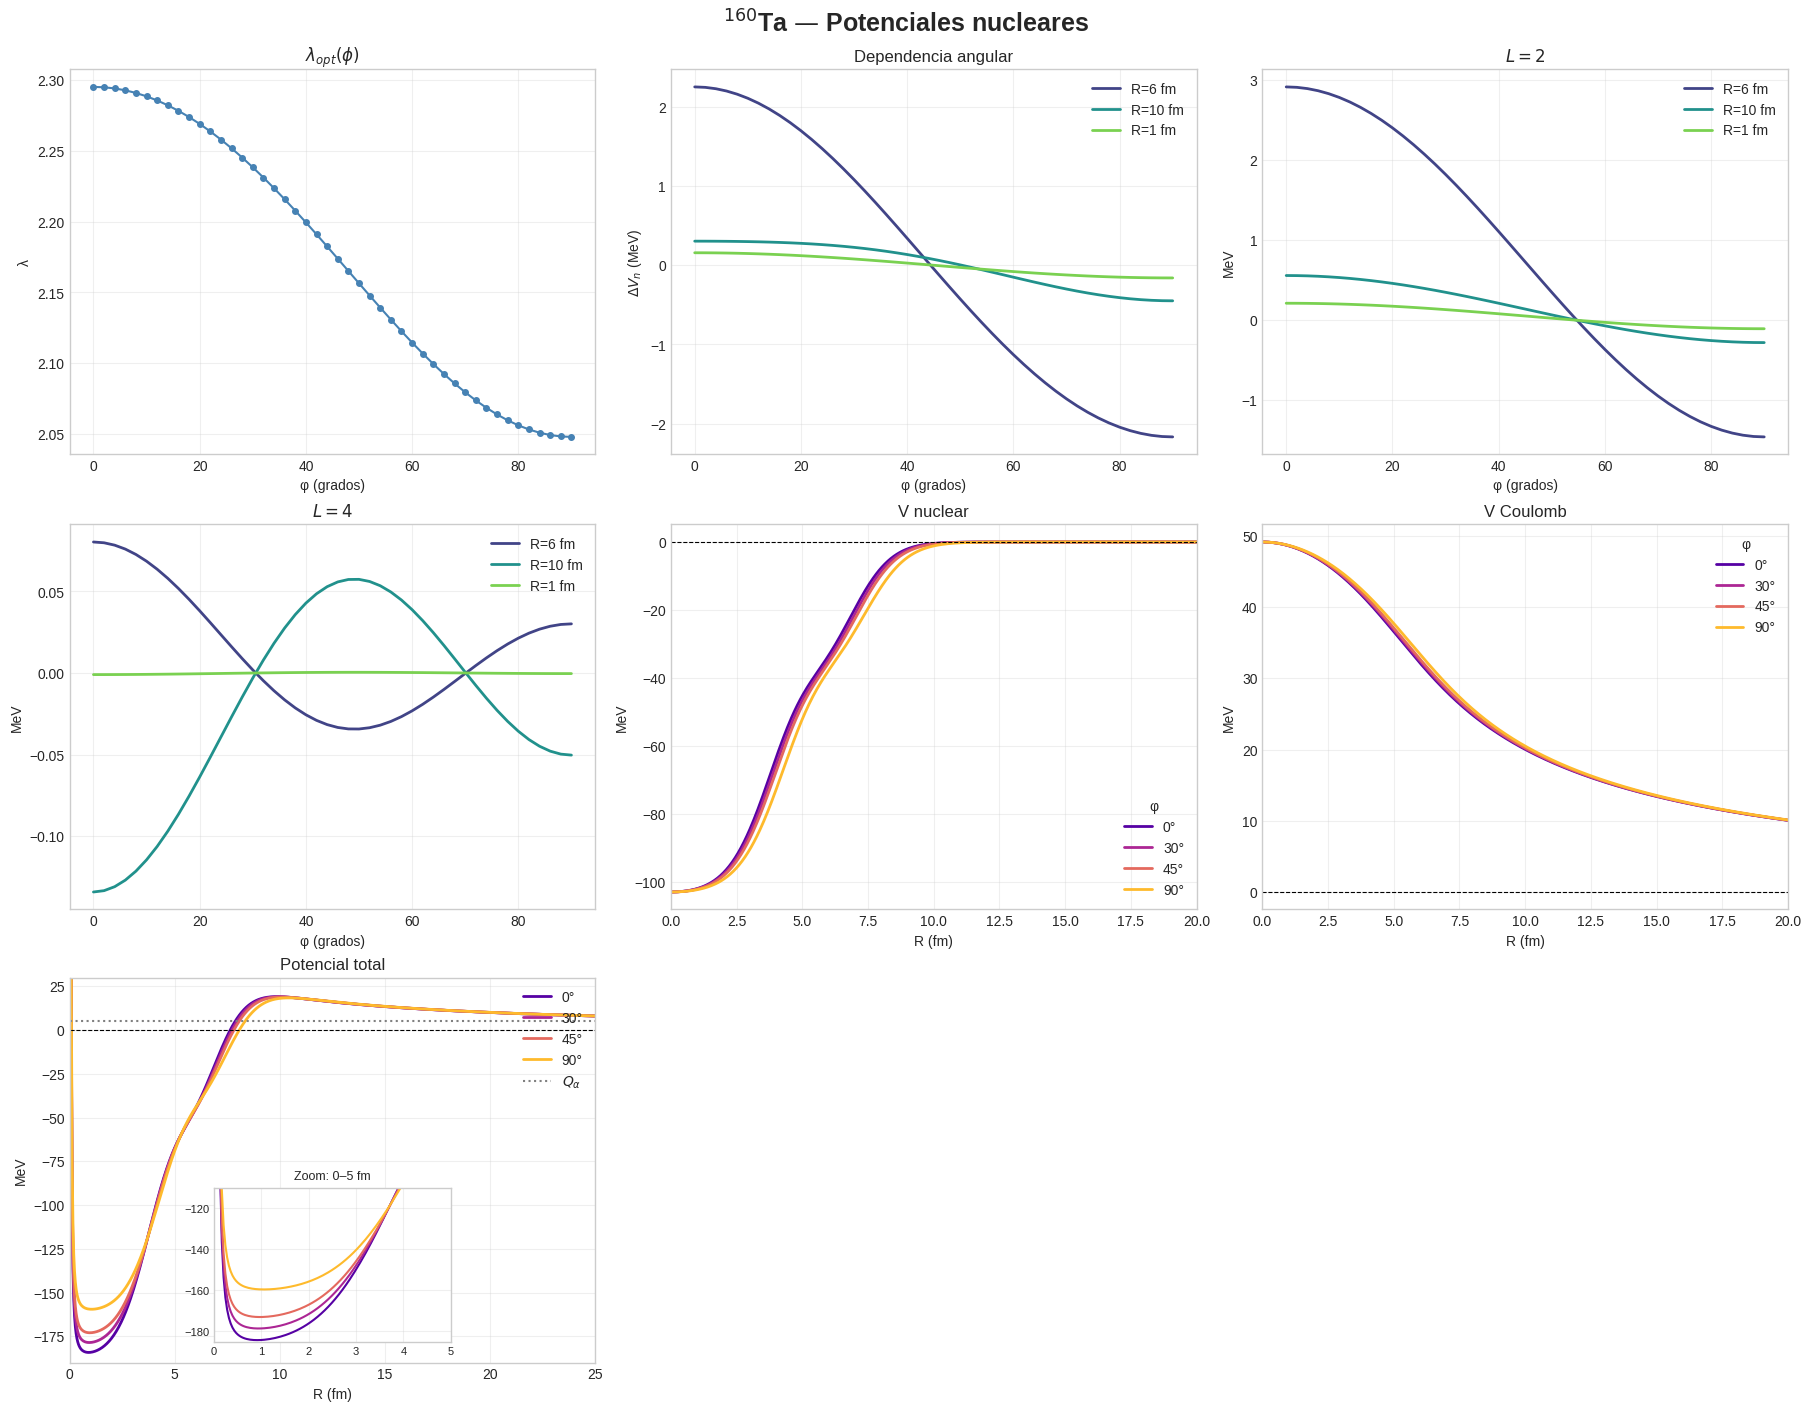

In [6]:
# Prove integral with decay 160-Ta
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad, simpson, dblquad
from scipy.interpolate import InterpolatedUnivariateSpline
from scipy.optimize import brentq
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# ─── Constantes ───────────────────────────────────────────────────────────────
Z_alpha = 2
Z_daugther = 71
e2 = 1.44
a_0 = 0.54
alpha = 0.7024
beta = 0.22
A_alpha = 4
A_daugther = 156
x = 7999 / 4
y = 2134 / 2.5
R_0 = 1.07 * (A_daugther) ** (1 / 3)
beta2 = -0.104
beta4 = 0.012
J00 = -275
Q_alpha = 5.4515
hbarc = 197.327
L = 0
G = 20
B = (G - L + 1) * (np.pi / 2)
m_n = 931.5
muc2 = (A_daugther * A_alpha) / (A_daugther + A_alpha) * m_n
zpb = (muc2 * (beta) ** 2) / (2 * (hbarc) ** 2)

# ─── Armónicos esféricos y geometría de la hija ──────────────────────────────
def Y00(theta): return np.sqrt(1 / (4 * np.pi))
def Y20(theta): return (1 / 4) * np.sqrt(5 / np.pi) * (3 * np.cos(theta) ** 2 - 1)
def Y40(theta): return (3 / 16) * np.sqrt(1 / np.pi) * (35 * np.cos(theta) ** 4 - 30 * np.cos(theta) ** 2 + 3)

def R_f_theta(theta):
    return R_0 * (1 + beta2 * Y20(theta) + beta4 * Y40(theta))

def a_f_theta(theta):
    a_perp = a_0 * (1 + beta2 * Y20(theta) + beta4 * Y40(theta))
    gradR = (R_0 / R_f_theta(theta)) * (
        -(3 / 2) * np.sqrt(5 / np.pi) * beta2 * np.cos(theta) * np.sin(theta)
        - (105 / 4) * np.sqrt(1 / np.pi) * beta4 * np.cos(theta) ** 3 * np.sin(theta)
        + (45 / 4) * np.sqrt(1 / np.pi) * beta4 * np.cos(theta) * np.sin(theta)
    )
    return a_perp * np.sqrt(1 + np.abs(gradR) ** 2)

# ─── Grillas ─────────────────────────────────────────────────────────────────
rmalla = np.linspace(0.01, 25, 500)
theta = np.linspace(0, np.pi, 250)
r2, Theta = np.meshgrid(rmalla, theta, indexing='ij')  # (r, θ)

k = np.linspace(0.001, 25, 400)
R = np.linspace(0.05, 30, 800)
phi = np.linspace(0, np.pi/2, 46)

# Densidad de Fermi (grilla r×θ) — calculada una sola vez
fermi_2D = 1.0 / (1.0 + np.exp((r2 - R_f_theta(Theta)) / a_f_theta(Theta)))

# ─── Funciones de Bessel esféricas ───────────────────────────────────────────
# Versión vectorizada (soporta arrays 2-D)
def j0_f(x): return np.sin(x) / x
def j2_f(x): return (3 / x**2 - 1) * np.sin(x) / x - 3 * np.cos(x) / x**2
def j4_f(x): return ((105 / x**5) - (45 / x**3) + (1 / x)) * np.sin(x) - ((105 / x**4) - (10 / x**2)) * np.cos(x)

# ─── Normalización densidad nuclear hija ─────────────────────────────────────
def rho2_integrand(theta, r):
    return (1 / (1 + np.exp((r - R_f_theta(theta)) / a_f_theta(theta)))) * r**2 * np.sin(theta)

I_rho2, _ = dblquad(rho2_integrand, 0.01, 15, 0, np.pi)
rho2_norm = A_daugther / (2 * np.pi * I_rho2)
rho2_norm_coulomb = Z_daugther / (2 * np.pi * I_rho2)  # misma integral geométrica

# ─── Transformadas de Fourier de ρ₂ (vectorizadas) ──────────────────────────
# Grilla para la integración: r(eje 0), θ(eje 1), k(eje 2)
# Se construye una vez y se usa para los seis momentos (L=0,2,4 × nuclear/Coulomb)

r3 = rmalla[:, None, None]   # (r, 1, 1)
Th3 = theta[None, :, None]   # (1, θ, 1)
k3 = k[None, None, :]        # (1, 1, k)

fermi_3D = 1.0 / (1.0 + np.exp((r3 - R_f_theta(Th3)) / a_f_theta(Th3)))
sin_Th = np.sin(Th3)

def fourier_rho2(norm, Ylm, jl, factor_4pi):
    # integrand shape: (r, θ, k)
    integrand = 2 * np.pi * norm * jl(r3 * k3) * Ylm(Th3) * r3**2 * sin_Th * fermi_3D
    int_r = simpson(integrand, x=rmalla, axis=0)  # (θ, k)
    return simpson(int_r, x=theta, axis=0)        # (k,)

# jl evaluados sobre la grilla r×k
rho2_fn0 = fourier_rho2(rho2_norm, Y00, j0_f, 1)
rho2_fn2 = fourier_rho2(rho2_norm, Y20, j2_f, 1)
rho2_fn4 = fourier_rho2(rho2_norm, Y40, j4_f, 1)

rho2_fc0 = fourier_rho2(rho2_norm_coulomb, Y00, j0_f, 1)
rho2_fc2 = fourier_rho2(rho2_norm_coulomb, Y20, j2_f, 1)
rho2_fc4 = fourier_rho2(rho2_norm_coulomb, Y40, j4_f, 1)

# ─── Transformadas de Fourier de ρ₁ (alfa — analíticas) ─────────────────────
I_r1, _ = quad(lambda r1: r1**2 * np.exp(-alpha * r1**2), 0, 15)
rho1_norm_c = Z_alpha / (4 * np.pi * I_r1)
gauss_k = np.exp(-k**2 / (4 * alpha))

rho1_fn = 0.4228 * (np.pi / alpha) ** 1.5 * gauss_k    # nuclear
rho1_fc = rho1_norm_c * (np.pi / alpha) ** 1.5 * gauss_k  # Coulomb

# ─── Potencial nuclear — integración en k vectorizada ────────────────────────
# V(R) = (2/π) · prefactor · ∫ ρ₁(k)·ρ₂L(k)·jL(kR)·k²·g(k) dk
# Grilla R×k:
Rm, km = np.meshgrid(R, k, indexing='ij')  # (R, k)
g_k = x / (k**2 + 4**2) - y / (k**2 + 2.5**2)

def V_nuclear_L(rho1, rho2_fL, jLN, prefactor):
    integrand = prefactor * rho1[None, :] * rho2_fL[None, :] * jLN(Rm * km) * km**2 * (4 * np.pi * g_k[None, :])
    return (2 / np.pi) * simpson(integrand, x=k, axis=1)  # (R,)

V_NN0 = V_nuclear_L(rho1_fn, rho2_fn0, j0_f, 1 / np.sqrt(4 * np.pi))
V_NN2 = V_nuclear_L(rho1_fn, rho2_fn2, j2_f, np.sqrt(5 / (4 * np.pi)))
V_NN4 = V_nuclear_L(rho1_fn, rho2_fn4, j4_f, np.sqrt(9 / (4 * np.pi)))

# ─── Potencial Coulomb — integración en k vectorizada ────────────────────────
def V_coulomb_L(rho1, rho2_fL, jLN, prefactor):
    integrand = prefactor * rho1[None, :] * rho2_fL[None, :] * jLN(Rm * km)
    return (2 * e2 / np.pi) * simpson(integrand, x=k, axis=1)

V_C0 = V_coulomb_L(rho1_fc, rho2_fc0, j0_f, 4 * np.pi / np.sqrt(4 * np.pi))
V_C2 = V_coulomb_L(rho1_fc, rho2_fc2, j2_f, 4 * np.pi * np.sqrt(5 / (4 * np.pi)))
V_C4 = V_coulomb_L(rho1_fc, rho2_fc4, j4_f, 4 * np.pi * np.sqrt(9 / (4 * np.pi)))

# ─── Polinomios de Legendre y ensamble final ──────────────────────────────────
def P2(phi): return 0.5 * (3 * np.cos(phi)**2 - 1)
def P4(phi): return (1 / 8) * (35 * np.cos(phi)**4 - 30 * np.cos(phi)**2 + 3)

# Potencial nuclear total: (R, φ)
V_Nuclear = (
    V_NN0[:, None]
    + V_NN2[:, None] * P2(phi)[None, :]
    + V_NN4[:, None] * P4(phi)[None, :]
)

# Potencial Coulomb total: (R, φ)
V_Coulomb = (
    V_C0[:, None]
    + V_C2[:, None] * P2(phi)[None, :]
    + V_C4[:, None] * P4(phi)[None, :]
)

# ─── Potencial centrífugo ─────────────────────────────────────────────────────
V_L = (hbarc**2 / (2 * muc2)) * ((L + 0.5)**2 / R**2)

def accion_phi_lam(lam, phi_idx):
    V_total = lam * V_Nuclear[:, phi_idx] + V_Coulomb[:, phi_idx] + V_L
    s = InterpolatedUnivariateSpline(R, Q_alpha - V_total, k=3)
    roots = s.roots()
    if len(roots) < 2:
        return None
    r1, r2 = roots[0], roots[-1]
    f = lambda r: np.sqrt(np.abs((2 * muc2 / hbarc**2) * s(r)))
    return quad(f, r1, r2, limit=200)[0]

lam_opt_vs_phi = []

for i, ph in enumerate(phi):
    try:
        # brentq encuentra el lambda donde S(λ) - B = 0
        lam_opt_i = brentq(
            lambda lam: accion_phi_lam(lam, i) - B,
            a=0.5, b=3.0,
            xtol=1e-4
        )
        lam_opt_vs_phi.append((ph, lam_opt_i))
        print(f"φ = {np.degrees(ph):6.1f}° → λ = {lam_opt_i:.4f}")
    except (ValueError, TypeError):
        lam_opt_vs_phi.append((ph, None))
        print(f"φ = {np.degrees(ph):6.1f}° → sin solución")


phi_arr = np.array([p for p, l in lam_opt_vs_phi if l is not None])
lam_arr = np.array([l for p, l in lam_opt_vs_phi if l is not None])
print('lambda promedio = ', np.around(np.sum(lam_arr)/37, 2))

plt.style.use('seaborn-v0_8-whitegrid')

idx1 = np.argmin(np.abs(R - 6))
idx2 = np.argmin(np.abs(R - 10))
idx3 = np.argmin(np.abs(R - 1))

phi_plot = [0, np.pi/6, np.pi/4, np.pi/2]
phi_lbls = ['0°', '30°', '45°', '90°']
phi_idxs = [np.argmin(np.abs(phi - p)) for p in phi_plot]

colors_ph = plt.cm.plasma(np.linspace(0.15, 0.85, len(phi_plot)))
colors_R = plt.cm.viridis(np.linspace(0.2, 0.8, 3))

fig, axs = plt.subplots(3, 3, figsize=(18, 14), constrained_layout=True)
fig.suptitle(r"$^{160}$Ta — Potenciales nucleares", fontsize=18, fontweight='bold')

# ─────────────────────────────────────────────
# [0,0] λ vs φ
axs[0,0].plot(np.degrees(phi_arr), lam_arr, '-o', ms=4, lw=1.5, color='steelblue')
axs[0,0].set(xlabel="φ (grados)", ylabel="λ", title=r"$\lambda_{opt}(\phi)$")
axs[0,0].grid(alpha=0.3)

# ─────────────────────────────────────────────
# [0,1] V_N vs φ (centrado)
for idx, lbl, col in zip([idx1, idx2, idx3], ['6 fm', '10 fm', '1 fm'], colors_R):
    V = V_Nuclear[idx,:]
    axs[0,1].plot(np.degrees(phi), V - np.mean(V), lw=2, label=f'R={lbl}', color=col)

axs[0,1].set(xlabel="φ (grados)", ylabel=r"$\Delta V_n$ (MeV)", title="Dependencia angular")
axs[0,1].legend(frameon=False)
axs[0,1].grid(alpha=0.3)

# ─────────────────────────────────────────────
# [0,2] L=2
for idx, lbl, col in zip([idx1, idx2, idx3], ['6 fm', '10 fm', '1 fm'], colors_R):
    axs[0,2].plot(np.degrees(phi), V_NN2[idx]*P2(phi), lw=2, label=f'R={lbl}', color=col)

axs[0,2].set(xlabel="φ (grados)", ylabel="MeV", title=r"$L=2$")
axs[0,2].legend(frameon=False)
axs[0,2].grid(alpha=0.3)

# ─────────────────────────────────────────────
# [1,0] L=4
for idx, lbl, col in zip([idx1, idx2, idx3], ['6 fm', '10 fm', '1 fm'], colors_R):
    axs[1,0].plot(np.degrees(phi), V_NN4[idx]*P4(phi), lw=2, label=f'R={lbl}', color=col)

axs[1,0].set(xlabel="φ (grados)", ylabel="MeV", title=r"$L=4$")
axs[1,0].legend(frameon=False)
axs[1,0].grid(alpha=0.3)

# ─────────────────────────────────────────────
# [1,1] V_N vs R
for pidx, lbl, col in zip(phi_idxs, phi_lbls, colors_ph):
    axs[1,1].plot(R, V_Nuclear[:, pidx], lw=2, label=lbl, color=col)

axs[1,1].set(xlabel="R (fm)", ylabel="MeV", title="V nuclear")
axs[1,1].axhline(0, color='black', lw=0.8, ls='--')
axs[1,1].set_xlim(0, 20)
axs[1,1].legend(title="φ")
axs[1,1].grid(alpha=0.3)

# ─────────────────────────────────────────────
# [1,2] V_C
for pidx, lbl, col in zip(phi_idxs, phi_lbls, colors_ph):
    axs[1,2].plot(R, V_Coulomb[:, pidx], lw=2, label=lbl, color=col)

axs[1,2].set(xlabel="R (fm)", ylabel="MeV", title="V Coulomb")
axs[1,2].axhline(0, color='black', lw=0.8, ls='--')
axs[1,2].set_xlim(0, 20)
axs[1,2].legend(title="φ")
axs[1,2].grid(alpha=0.3)

# ─────────────────────────────────────────────
# [2,0] V total
lam_interp = np.interp(phi, phi_arr, lam_arr)
for pidx, lbl, col in zip(phi_idxs, phi_lbls, colors_ph):
    V_tot = lam_interp[pidx]*V_Nuclear[:,pidx] + V_Coulomb[:,pidx] + V_L
    axs[2,0].plot(R, V_tot, lw=2, label=lbl, color=col)
axs[2,0].axhline(Q_alpha, color='gray', lw=1.5, ls=':', label=r"$Q_\alpha$")
axs[2,0].axhline(0, color='black', lw=0.8, ls='--')
axs[2,0].set(xlabel="R (fm)", ylabel="MeV", title="Potencial total")
axs[2,0].set_xlim(0, 25)
axs[2,0].set_ylim(-190, 30)
axs[2,0].legend(loc='upper right')
axs[2,0].grid(alpha=0.3)

# ─────────── INSET: zoom 0 a 5 fm (abajo a la derecha) ───────────
axins = inset_axes(axs[2,0], width="45%", height="40%",
                   loc='lower center', borderpad=1.5)
for pidx, lbl, col in zip(phi_idxs, phi_lbls, colors_ph):
    V_tot = lam_interp[pidx]*V_Nuclear[:,pidx] + V_Coulomb[:,pidx] + V_L
    axins.plot(R, V_tot, lw=1.5, color=col)
axins.axhline(Q_alpha, color='gray', lw=1, ls=':')
axins.axhline(0, color='black', lw=0.6, ls='--')
axins.set_xlim(0, 5)
axins.set_ylim(-185, -110)
axins.set_title('Zoom: 0–5 fm', fontsize=9)
axins.tick_params(labelsize=8)
axins.grid(alpha=0.3)


axs[2,1].axis('off')
axs[2,2].axis('off')
plt.show()

In [1]:
# 236-U  —  caso ESFÉRICO (beta2 = beta4 = 0)
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad, simpson, dblquad
from scipy.interpolate import InterpolatedUnivariateSpline
from scipy.optimize import brentq

# ─── Constantes ───────────────────────────────────────────────────────────────
Z_alpha    = 2
Z_daugther = 90
e2         = 1.44
a_0        = 0.54
alpha      = 0.7024
beta       = 0.22
A_alpha    = 4
A_daugther = 232
x          = 7999 / 4
y          = 2134 / 2.5
R_0        = 1.07 * (A_daugther) ** (1 / 3)

# ─── DEFORMACIÓN APAGADA ──────────────────────────────────────────────────────
beta2      = 0.0
beta4      = 0.0

J00        = -275
Q_alpha    = 4.57
hbarc      = 197.327
L          = 0
G          = 22
B          = (G - L + 1) * (np.pi / 2)
m_n        = 931.5
muc2       = (A_daugther * A_alpha) / (A_daugther + A_alpha) * m_n
zpb        = (muc2 * (beta) ** 2) / (2 * (hbarc) ** 2)

# ─── Armónicos esféricos y geometría de la hija ──────────────────────────────
def Y00(theta): return np.sqrt(1 / (4 * np.pi))
def Y20(theta): return (1 / 4) * np.sqrt(5 / np.pi) * (3 * np.cos(theta) ** 2 - 1)
def Y40(theta): return (3 / 16) * np.sqrt(1 / np.pi) * (35 * np.cos(theta) ** 4 - 30 * np.cos(theta) ** 2 + 3)

def R_f_theta(theta):
    return R_0 * (1 + beta2 * Y20(theta) + beta4 * Y40(theta))

def a_f_theta(theta):
    a_perp = a_0 * (1 + beta2 * Y20(theta) + beta4 * Y40(theta))
    gradR  = (R_0 / R_f_theta(theta)) * (
        -(3 / 2) * np.sqrt(5 / np.pi) * beta2 * np.cos(theta) * np.sin(theta)
        - (105 / 4) * np.sqrt(1 / np.pi) * beta4 * np.cos(theta) ** 3 * np.sin(theta)
        + (45  / 4) * np.sqrt(1 / np.pi) * beta4 * np.cos(theta) * np.sin(theta)
    )
    return a_perp * np.sqrt(1 + np.abs(gradR) ** 2)

# ─── Grillas ─────────────────────────────────────────────────────────────────
rmalla = np.linspace(0.01, 25, 500)
theta  = np.linspace(0, np.pi, 250)

k   = np.linspace(0.001, 25, 400)
R   = np.linspace(0.05, 100, 1000)
phi = np.linspace(0, np.pi/2, 46)

# ─── Funciones de Bessel esféricas ───────────────────────────────────────────
def j0_f(x): return np.sin(x) / x
def j2_f(x): return (3 / x**2 - 1) * np.sin(x) / x - 3 * np.cos(x) / x**2
def j4_f(x): return ((105 / x**5) - (45 / x**3) + (1 / x)) * np.sin(x) - ((105 / x**4) - (10 / x**2)) * np.cos(x)

# ─── Normalización densidad nuclear hija ─────────────────────────────────────
def rho2_integrand(theta, r):
    return (1 / (1 + np.exp((r - R_f_theta(theta)) / a_f_theta(theta)))) * r**2 * np.sin(theta)

I_rho2, _ = dblquad(rho2_integrand, 0.01, 15, 0, np.pi)
rho2_norm         = A_daugther / (2 * np.pi * I_rho2)
rho2_norm_coulomb = Z_daugther / (2 * np.pi * I_rho2)

# ─── Transformadas de Fourier de ρ₂ (vectorizadas) ──────────────────────────
r3   = rmalla[:, None, None]
Th3  = theta[None, :, None]
k3   = k[None, None, :]

fermi_3D = 1.0 / (1.0 + np.exp((r3 - R_f_theta(Th3)) / a_f_theta(Th3)))
sin_Th   = np.sin(Th3)

def fourier_rho2(norm, Ylm, jl, factor_4pi):
    integrand = 2 * np.pi * norm * jl(r3 * k3) * Ylm(Th3) * r3**2 * sin_Th * fermi_3D
    int_r  = simpson(integrand, x=rmalla, axis=0)
    return simpson(int_r, x=theta, axis=0)

rho2_fn0 = fourier_rho2(rho2_norm,         Y00, j0_f, 1)
rho2_fn2 = fourier_rho2(rho2_norm,         Y20, j2_f, 1)
rho2_fn4 = fourier_rho2(rho2_norm,         Y40, j4_f, 1)

rho2_fc0 = fourier_rho2(rho2_norm_coulomb, Y00, j0_f, 1)
rho2_fc2 = fourier_rho2(rho2_norm_coulomb, Y20, j2_f, 1)
rho2_fc4 = fourier_rho2(rho2_norm_coulomb, Y40, j4_f, 1)

# ─── Transformadas de Fourier de ρ₁ (alfa — analíticas) ─────────────────────
I_r1, _     = quad(lambda r1: r1**2 * np.exp(-alpha * r1**2), 0, 15)
rho1_norm_c = Z_alpha / (4 * np.pi * I_r1)
gauss_k     = np.exp(-k**2 / (4 * alpha))

rho1_fn = 0.4228 * (np.pi / alpha) ** 1.5 * gauss_k
rho1_fc = rho1_norm_c * (np.pi / alpha) ** 1.5 * gauss_k

# ─── Potencial nuclear ────────────────────────────────────────────────────────
Rm, km = np.meshgrid(R, k, indexing='ij')
g_k    = x / (k**2 + 4**2) - y / (k**2 + 2.5**2)

def V_nuclear_L(rho1, rho2_fL, jLN, prefactor):
    integrand = prefactor * rho1[None, :] * rho2_fL[None, :] * jLN(Rm * km) * km**2 * (4 * np.pi * g_k[None, :])
    return (2 / np.pi) * simpson(integrand, x=k, axis=1)

V_NN0 = V_nuclear_L(rho1_fn, rho2_fn0, j0_f, 1 / np.sqrt(4 * np.pi))
V_NN2 = V_nuclear_L(rho1_fn, rho2_fn2, j2_f, np.sqrt(5 / (4 * np.pi)))
V_NN4 = V_nuclear_L(rho1_fn, rho2_fn4, j4_f, np.sqrt(9 / (4 * np.pi)))

# ─── Potencial Coulomb ────────────────────────────────────────────────────────
def V_coulomb_L(rho1, rho2_fL, jLN, prefactor):
    integrand = prefactor * rho1[None, :] * rho2_fL[None, :] * jLN(Rm * km)
    return (2 * e2 / np.pi) * simpson(integrand, x=k, axis=1)

V_C0 = V_coulomb_L(rho1_fc, rho2_fc0, j0_f, 4 * np.pi / np.sqrt(4 * np.pi))
V_C2 = V_coulomb_L(rho1_fc, rho2_fc2, j2_f, 4 * np.pi * np.sqrt(5  / (4 * np.pi)))
V_C4 = V_coulomb_L(rho1_fc, rho2_fc4, j4_f, 4 * np.pi * np.sqrt(9  / (4 * np.pi)))

# ─── Legendre y ensamble (esférico → solo monopolo sobrevive) ────────────────
def P2(phi): return 0.5 * (3 * np.cos(phi)**2 - 1)
def P4(phi): return (1 / 8) * (35 * np.cos(phi)**4 - 30 * np.cos(phi)**2 + 3)

V_Nuclear = (V_NN0[:, None] + V_NN2[:, None] * P2(phi)[None, :] + V_NN4[:, None] * P4(phi)[None, :])
V_Coulomb = (V_C0[:, None]  + V_C2[:, None]  * P2(phi)[None, :] + V_C4[:, None]  * P4(phi)[None, :])

# ─── Potencial centrífugo ─────────────────────────────────────────────────────
V_L = (hbarc**2 / (2 * muc2)) * ((L + 0.5)**2 / R**2)

# Diagnóstico: cuánto valen las componentes L=2,4 (deberían ser ~0)
print(f"max |V_NN2| = {np.max(np.abs(V_NN2)):.3e} MeV  (debe ser ~0)")
print(f"max |V_NN4| = {np.max(np.abs(V_NN4)):.3e} MeV  (debe ser ~0)")
print(f"max |V_C2|  = {np.max(np.abs(V_C2)):.3e} MeV  (debe ser ~0)")
print(f"max |V_C4|  = {np.max(np.abs(V_C4)):.3e} MeV  (debe ser ~0)")

# ─── λ óptimo (sin dependencia angular: un solo valor) ───────────────────────
def accion_phi_lam(lam, phi_idx):
    V_total = lam * V_Nuclear[:, phi_idx] + V_Coulomb[:, phi_idx] + V_L
    s = InterpolatedUnivariateSpline(R, Q_alpha - V_total, k=3)
    roots = s.roots()
    if len(roots) < 2:
        return None
    r1, r2 = roots[0], roots[1]
    f = lambda r: np.sqrt(np.abs((2 * muc2 / hbarc**2) * s(r)))
    return quad(f, r1, r2, limit=200)[0]

try:
    lam_opt = brentq(lambda lam: accion_phi_lam(lam, 0) - B, a=0.5, b=3.0, xtol=1e-4)
    print(f"φ = {np.degrees(ph):6.1f}° → λ = {lam_opt:.4f}")
    print(f"\nλ óptimo (esférico) = {lam_opt:.4f}")
except (ValueError, TypeError):
    lam_opt = 1.0
    print("\nSin solución para λ — uso λ = 1.0")

# Como no hay dependencia angular, basta φ = 0 (pidx=0) para todas las curvas
pidx = 0
VN  = V_Nuclear[:, pidx]
VC  = V_Coulomb[:, pidx]
Vtot = lam_opt * VN + VC + V_L

# ─── GRÁFICAS ─────────────────────────────────────────────────────────────────
plt.style.use('seaborn-v0_8-whitegrid')
fig, axs = plt.subplots(1, 3, figsize=(18, 5.5), constrained_layout=True)
fig.suptitle(r"$^{236}$U — Potenciales con $\beta_2=\beta_4=0$ (núcleo esférico)",
             fontsize=16, fontweight='bold')

# [0] Coulomb
axs[0].plot(R, VC, lw=2.2, color='#c0392b')
axs[0].axhline(0, color='black', lw=0.8, ls='--')
axs[0].set(xlabel="R (fm)", ylabel="V (MeV)", title="Potencial de Coulomb")
axs[0].set_xlim(0, 25)
axs[0].grid(alpha=0.3)

# [1] Nuclear
axs[1].plot(R, VN, lw=2.2, color='#2c7fb8')
axs[1].axhline(0, color='black', lw=0.8, ls='--')
axs[1].set(xlabel="R (fm)", ylabel="V (MeV)", title="Potencial nuclear")
axs[1].set_xlim(0, 25)
axs[1].grid(alpha=0.3)

# [2] Total
axs[2].plot(R, Vtot, lw=2.2, color='#27ae60', label=r"$\lambda\,V_N + V_C + V_\ell$")
axs[2].axhline(Q_alpha, color='gray', lw=1.5, ls=':', label=r"$Q_\alpha$")
axs[2].axhline(0, color='black', lw=0.8, ls='--')
axs[2].set(xlabel="R (fm)", ylabel="V (MeV)", title=f"Potencial total (λ={lam_opt:.3f})")
axs[2].set_xlim(0, 25)
axs[2].set_ylim(-180, 30)
axs[2].legend(loc='upper right', frameon=True)
axs[2].grid(alpha=0.3)

#plt.savefig('/home/claude/u236_esferico.png', dpi=150, bbox_inches='tight')
print("Figura guardada.")

max |V_NN2| = 1.369e-06 MeV  (debe ser ~0)
max |V_NN4| = 5.605e-06 MeV  (debe ser ~0)
max |V_C2|  = 1.726e-07 MeV  (debe ser ~0)
max |V_C4|  = 3.193e-07 MeV  (debe ser ~0)


NameError: name 'ph' is not defined

Calculando caso esférico (β=0)...
  λ esférico = 2.0282
Calculando caso deformado (β₂=0.207, β₄=0.108)...
[1.66574601 1.66672757 1.66966845 1.67455696 1.68137286 1.69008615
 1.70065549 1.71302604 1.72712694 1.74286847 1.76013913 1.7788029
 1.79869728 1.81963288 1.84139508 1.86374859 1.88644487 1.90923167
 1.93186338 1.95411045 1.9757662  1.99665083 2.01661265 2.03552731
 2.05329628 2.06984498 2.08512113 2.09909335 2.11175004 2.1230984
 2.13316334 2.14198633 2.14962387 2.15614587 2.16163239 2.16617447
 2.16986923 2.17281721 2.17511977 2.17687612 2.17818027 2.17911804
 2.17976424 2.18018005 2.18041088 2.18048468]


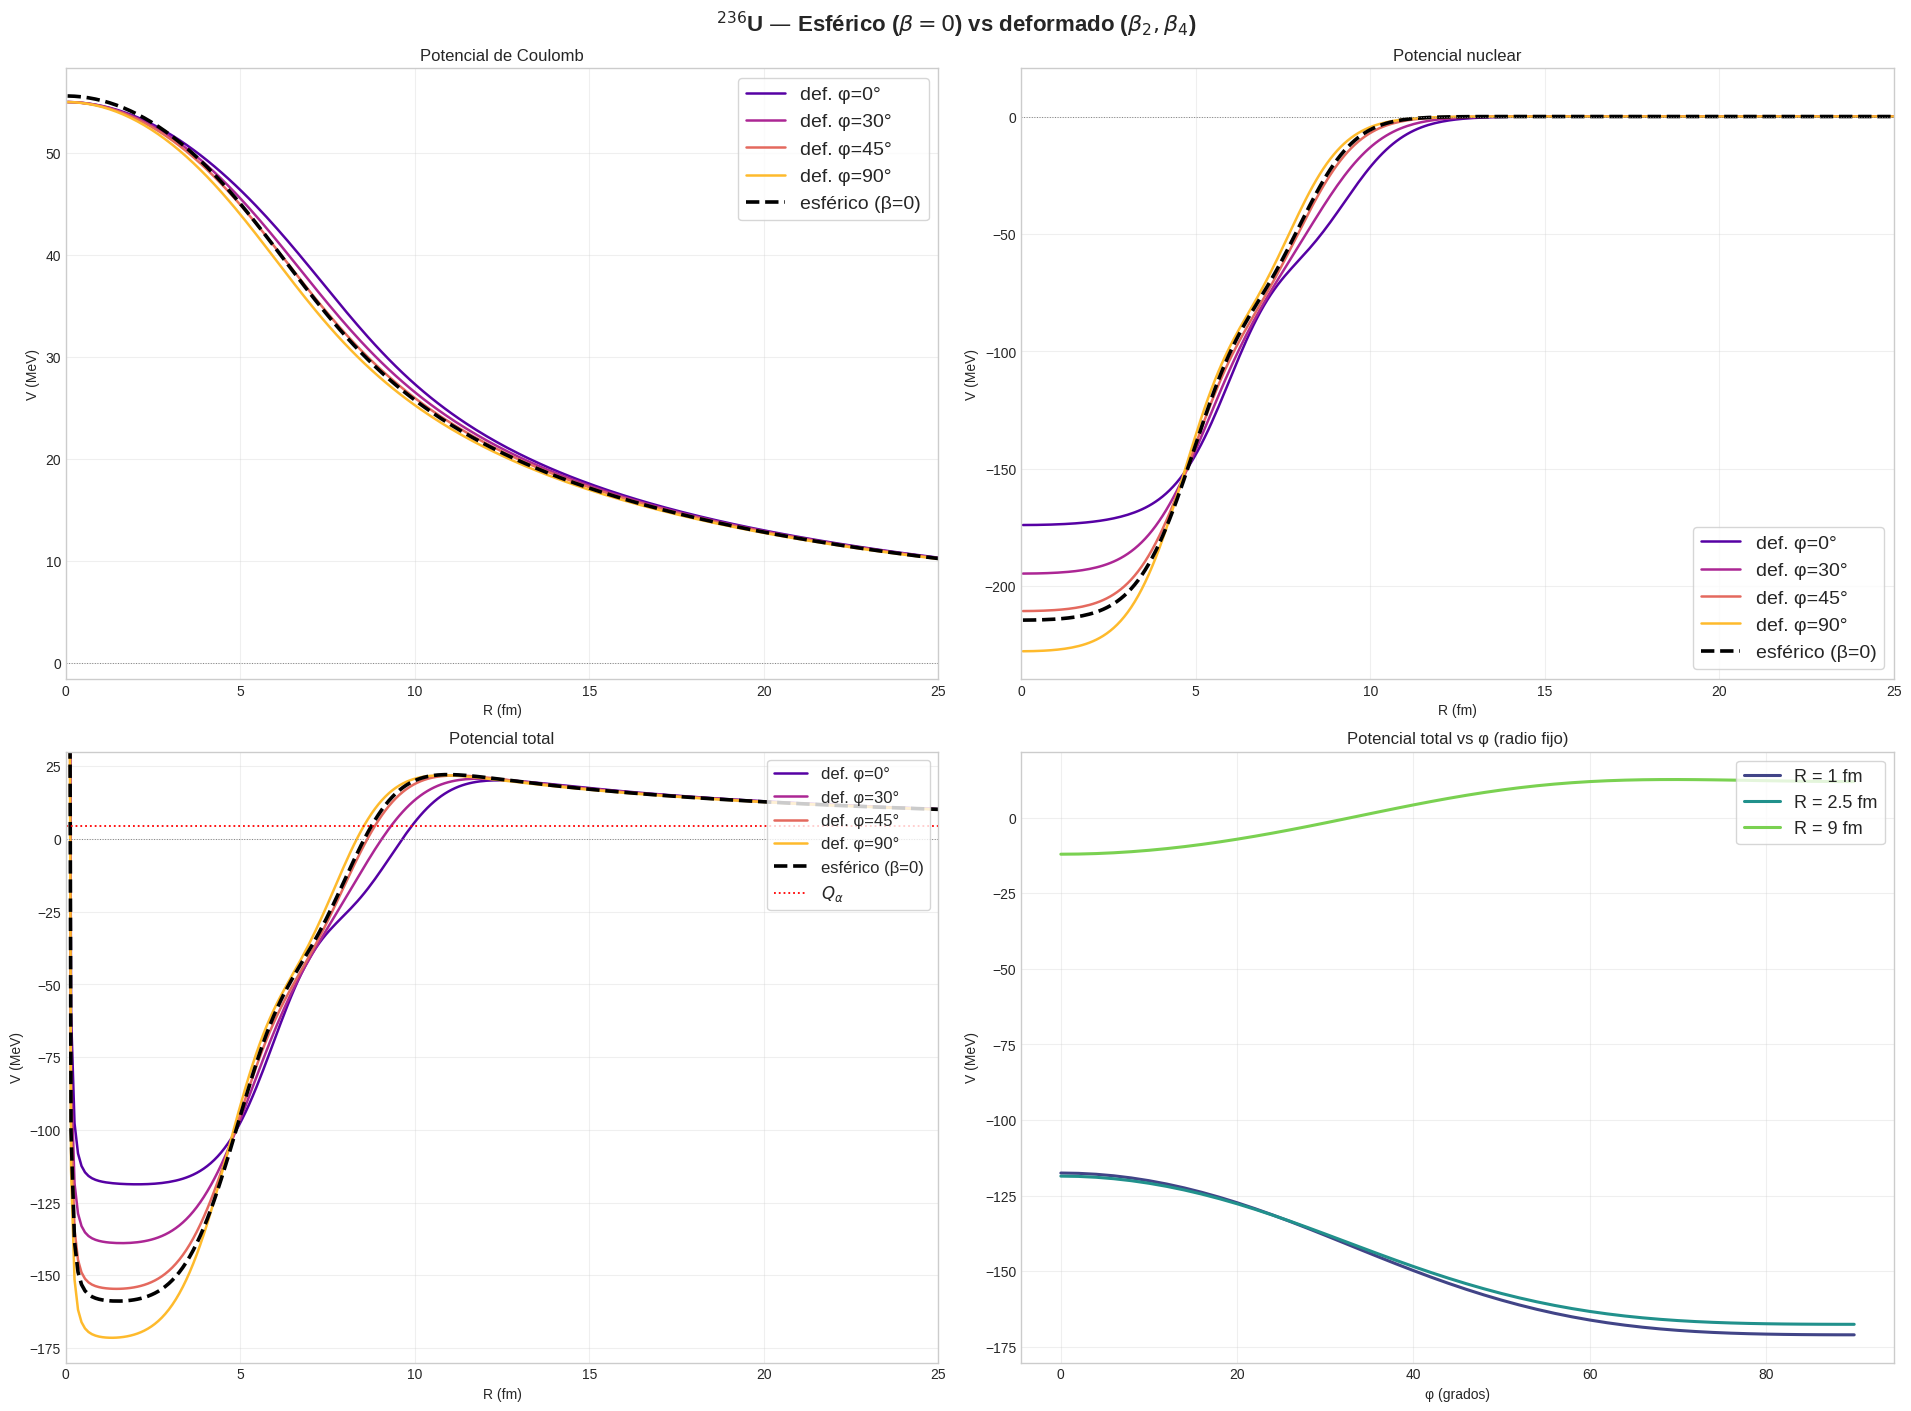

In [9]:
# 236-U  —  COMPARACIÓN: esférico (β=0) vs deformado (β₂, β₄) en un mismo plot
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad, simpson, dblquad
from scipy.interpolate import InterpolatedUnivariateSpline
from scipy.optimize import brentq

# ─── Constantes globales ──────────────────────────────────────────────────────
Z_alpha    = 2
Z_daugther = 90
e2         = 1.44
a_0        = 0.54
alpha      = 0.7024
beta       = 0.22
A_alpha    = 4
A_daugther = 232
x          = 7999 / 4
y          = 2134 / 2.5
R_0        = 1.07 * (A_daugther) ** (1 / 3)
Q_alpha    = 4.57
hbarc      = 197.327
L          = 0
G          = 22
B          = (G - L + 1) * (np.pi / 2)
m_n        = 931.5
muc2       = (A_daugther * A_alpha) / (A_daugther + A_alpha) * m_n

# ─── Grillas ─────────────────────────────────────────────────────────────────
rmalla = np.linspace(0.01, 25, 500)
theta  = np.linspace(0, np.pi, 250)
k      = np.linspace(0.001, 25, 400)
R      = np.linspace(0.05, 100, 1000)
phi    = np.linspace(0, np.pi/2, 46)

# ─── Armónicos esféricos ──────────────────────────────────────────────────────
def Y00(t): return np.sqrt(1 / (4 * np.pi))
def Y20(t): return (1 / 4) * np.sqrt(5 / np.pi) * (3 * np.cos(t) ** 2 - 1)
def Y40(t): return (3 / 16) * np.sqrt(1 / np.pi) * (35 * np.cos(t) ** 4 - 30 * np.cos(t) ** 2 + 3)

# ─── Bessel esféricas ─────────────────────────────────────────────────────────
def j0_f(x): return np.sin(x) / x
def j2_f(x): return (3 / x**2 - 1) * np.sin(x) / x - 3 * np.cos(x) / x**2
def j4_f(x): return ((105 / x**5) - (45 / x**3) + (1 / x)) * np.sin(x) - ((105 / x**4) - (10 / x**2)) * np.cos(x)

# ─── Legendre ─────────────────────────────────────────────────────────────────
def P2(p): return 0.5 * (3 * np.cos(p)**2 - 1)
def P4(p): return (1 / 8) * (35 * np.cos(p)**4 - 30 * np.cos(p)**2 + 3)

# ─── Potencial centrífugo (no depende de β) ──────────────────────────────────
V_L = (hbarc**2 / (2 * muc2)) * ((L + 0.5)**2 / R**2)

# precálculos que no dependen de β
Rm, km  = np.meshgrid(R, k, indexing='ij')
g_k     = x / (k**2 + 4**2) - y / (k**2 + 2.5**2)
I_r1, _ = quad(lambda r1: r1**2 * np.exp(-alpha * r1**2), 0, 15)
rho1_norm_c = Z_alpha / (4 * np.pi * I_r1)
gauss_k = np.exp(-k**2 / (4 * alpha))
rho1_fn = 0.4228 * (np.pi / alpha) ** 1.5 * gauss_k
rho1_fc = rho1_norm_c * (np.pi / alpha) ** 1.5 * gauss_k


def compute_case(beta2, beta4):
    """Devuelve V_Nuclear(R,φ) y V_Coulomb(R,φ) para los β dados."""

    def R_f(t):
        return R_0 * (1 + beta2 * Y20(t) + beta4 * Y40(t))

    def a_f(t):
        a_perp = a_0 * (1 + beta2 * Y20(t) + beta4 * Y40(t))
        gradR  = (R_0 / R_f(t)) * (
            -(3 / 2) * np.sqrt(5 / np.pi) * beta2 * np.cos(t) * np.sin(t)
            - (105 / 4) * np.sqrt(1 / np.pi) * beta4 * np.cos(t) ** 3 * np.sin(t)
            + (45  / 4) * np.sqrt(1 / np.pi) * beta4 * np.cos(t) * np.sin(t)
        )
        return a_perp * np.sqrt(1 + np.abs(gradR) ** 2)

    # normalización
    def rho2_integrand(t, r):
        return (1 / (1 + np.exp((r - R_f(t)) / a_f(t)))) * r**2 * np.sin(t)
    I_rho2, _ = dblquad(rho2_integrand, 0.01, 15, 0, np.pi)
    rho2_norm         = A_daugther / (2 * np.pi * I_rho2)
    rho2_norm_coulomb = Z_daugther / (2 * np.pi * I_rho2)

    # FT de ρ₂
    r3  = rmalla[:, None, None]
    Th3 = theta[None, :, None]
    k3  = k[None, None, :]
    fermi_3D = 1.0 / (1.0 + np.exp((r3 - R_f(Th3)) / a_f(Th3)))
    sin_Th   = np.sin(Th3)

    def fourier_rho2(norm, Ylm, jl):
        integrand = 2 * np.pi * norm * jl(r3 * k3) * Ylm(Th3) * r3**2 * sin_Th * fermi_3D
        return simpson(simpson(integrand, x=rmalla, axis=0), x=theta, axis=0)

    rho2_fn0 = fourier_rho2(rho2_norm,         Y00, j0_f)
    rho2_fn2 = fourier_rho2(rho2_norm,         Y20, j2_f)
    rho2_fn4 = fourier_rho2(rho2_norm,         Y40, j4_f)
    rho2_fc0 = fourier_rho2(rho2_norm_coulomb, Y00, j0_f)
    rho2_fc2 = fourier_rho2(rho2_norm_coulomb, Y20, j2_f)
    rho2_fc4 = fourier_rho2(rho2_norm_coulomb, Y40, j4_f)

    # potencial nuclear
    def V_nuc(rho1, rho2_fL, jLN, pref):
        integrand = pref * rho1[None, :] * rho2_fL[None, :] * jLN(Rm * km) * km**2 * (4 * np.pi * g_k[None, :])
        return (2 / np.pi) * simpson(integrand, x=k, axis=1)
    V_NN0 = V_nuc(rho1_fn, rho2_fn0, j0_f, 1 / np.sqrt(4 * np.pi))
    V_NN2 = V_nuc(rho1_fn, rho2_fn2, j2_f, np.sqrt(5 / (4 * np.pi)))
    V_NN4 = V_nuc(rho1_fn, rho2_fn4, j4_f, np.sqrt(9 / (4 * np.pi)))

    # potencial Coulomb
    def V_coul(rho1, rho2_fL, jLN, pref):
        integrand = pref * rho1[None, :] * rho2_fL[None, :] * jLN(Rm * km)
        return (2 * e2 / np.pi) * simpson(integrand, x=k, axis=1)
    V_C0 = V_coul(rho1_fc, rho2_fc0, j0_f, 4 * np.pi / np.sqrt(4 * np.pi))
    V_C2 = V_coul(rho1_fc, rho2_fc2, j2_f, 4 * np.pi * np.sqrt(5 / (4 * np.pi)))
    V_C4 = V_coul(rho1_fc, rho2_fc4, j4_f, 4 * np.pi * np.sqrt(9 / (4 * np.pi)))

    V_Nuclear = V_NN0[:, None] + V_NN2[:, None] * P2(phi)[None, :] + V_NN4[:, None] * P4(phi)[None, :]
    V_Coulomb = V_C0[:, None]  + V_C2[:, None]  * P2(phi)[None, :] + V_C4[:, None]  * P4(phi)[None, :]
    return V_Nuclear, V_Coulomb


def lambda_optimo(V_Nuclear, V_Coulomb, phi_idx):
    def accion(lam):
        Vt = lam * V_Nuclear[:, phi_idx] + V_Coulomb[:, phi_idx] + V_L
        s = InterpolatedUnivariateSpline(R, Q_alpha - Vt, k=3)
        roots = s.roots()
        if len(roots) < 2:
            return None
        r1, r2 = roots[0], roots[1]
        f = lambda r: np.sqrt(np.abs((2 * muc2 / hbarc**2) * s(r)))
        return quad(f, r1, r2, limit=200)[0]
    try:
        return brentq(lambda lam: accion(lam) - B, a=0.5, b=3.0, xtol=1e-4)
    except (ValueError, TypeError):
        return None


# ─── Caso ESFÉRICO ────────────────────────────────────────────────────────────
print("Calculando caso esférico (β=0)...")
VN_sph, VC_sph = compute_case(0.0, 0.0)
lam_sph = lambda_optimo(VN_sph, VC_sph, 0) or 1.0
print(f"  λ esférico = {lam_sph:.4f}")

# ─── Caso DEFORMADO ───────────────────────────────────────────────────────────
print("Calculando caso deformado (β₂=0.207, β₄=0.108)...")
VN_def, VC_def = compute_case(0.207, 0.108)
# λ óptimo por ángulo
lam_phi = []
for i in range(len(phi)):
    li = lambda_optimo(VN_def, VC_def, i)
    lam_phi.append(li)
phi_ok  = np.array([phi[i] for i, l in enumerate(lam_phi) if l is not None])
lam_ok  = np.array([l for l in lam_phi if l is not None])
lam_interp = np.interp(phi, phi_ok, lam_ok)
#print(f"  λ deformado promedio = {np.mean(lam_ok):.4f}")
print(lam_ok)
# ─── Ángulos a graficar (deformado) ───────────────────────────────────────────
phi_plot = [0, np.pi/6, np.pi/4, np.pi/2]
phi_lbls = ['0°', '30°', '45°', '90°']
phi_idxs = [np.argmin(np.abs(phi - p)) for p in phi_plot]
colors_ph = plt.cm.plasma(np.linspace(0.15, 0.85, len(phi_plot)))

# ─── GRÁFICAS ─────────────────────────────────────────────────────────────────
plt.style.use('seaborn-v0_8-whitegrid')
fig, axs = plt.subplots(2, 2, figsize=(19, 14), constrained_layout=True)
fig.suptitle(r"$^{236}$U — Esférico ($\beta=0$) vs deformado ($\beta_2,\beta_4$)",
             fontsize=16, fontweight='bold')

# [0] COULOMB
for pidx, lbl, col in zip(phi_idxs, phi_lbls, colors_ph):
    axs[0,0].plot(R, VC_def[:, pidx], lw=1.8, color=col, label=f'def. φ={lbl}')
axs[0,0].plot(R, VC_sph[:, 0], lw=2.6, color='black', ls='--', label='esférico (β=0)')
axs[0,0].axhline(0, color='gray', lw=0.7, ls=':')
axs[0,0].set(xlabel="R (fm)", ylabel="V (MeV)", title="Potencial de Coulomb")
axs[0,0].set_xlim(0, 25)
axs[0,0].legend(frameon=True, fontsize=14)
axs[0,0].grid(alpha=0.3)

# [1] NUCLEAR
for pidx, lbl, col in zip(phi_idxs, phi_lbls, colors_ph):
    axs[0,1].plot(R,  lam_interp[pidx]*VN_def[:, pidx], lw=1.8, color=col, label=f'def. φ={lbl}')
axs[0,1].plot(R, 2.02*VN_sph[:, 0], lw=2.6, color='black', ls='--', label='esférico (β=0)')
axs[0,1].axhline(0, color='gray', lw=0.7, ls=':')
axs[0,1].set(xlabel="R (fm)", ylabel="V (MeV)", title="Potencial nuclear")
axs[0,1].set_xlim(0, 25)
axs[0,1].legend(frameon=True, fontsize=14)
axs[0,1].grid(alpha=0.3)

# [2] TOTAL
for pidx, lbl, col in zip(phi_idxs, phi_lbls, colors_ph):
    Vt = lam_interp[pidx] * VN_def[:, pidx] + VC_def[:, pidx] + V_L
    axs[1,0].plot(R, Vt, lw=1.8, color=col, label=f'def. φ={lbl}')
Vt_sph = lam_sph * VN_sph[:, 0] + VC_sph[:, 0] + V_L
axs[1,0].plot(R, Vt_sph, lw=2.6, color='black', ls='--', label='esférico (β=0)')
axs[1,0].axhline(Q_alpha, color='red', lw=1.3, ls=':', label=r"$Q_\alpha$")
axs[1,0].axhline(0, color='gray', lw=0.7, ls=':')
axs[1,0].set(xlabel="R (fm)", ylabel="V (MeV)", title="Potencial total")
axs[1,0].set_xlim(0, 25)
axs[1,0].set_ylim(-180, 30)
axs[1,0].legend(frameon=True, fontsize=12, loc='upper right')
axs[1,0].grid(alpha=0.3)

R_fix    = [1, 2.5, 9]
ridxs    = [np.argmin(np.abs(R - rf)) for rf in R_fix]
colors_R = plt.cm.viridis(np.linspace(0.2, 0.8, len(R_fix)))

for ridx, rf, col in zip(ridxs, R_fix, colors_R):
    Vt_phi = lam_interp * VN_def[ridx, :] + VC_def[ridx, :] + V_L[ridx] #VN_def[ridx, :] o VC_def[ridx, :]
    axs[1,1].plot(np.degrees(phi), Vt_phi, lw=2.2, color=col, label=f'R = {rf} fm')
axs[1,1].set(xlabel="φ (grados)", ylabel="V (MeV)", title="Potencial total vs φ (radio fijo)")
#axs[1,1].set_yscale('log')
axs[1,1].legend(frameon=True, fontsize=13, loc='upper right')
axs[1,1].grid(alpha=0.3)


plt.savefig('informe.png')

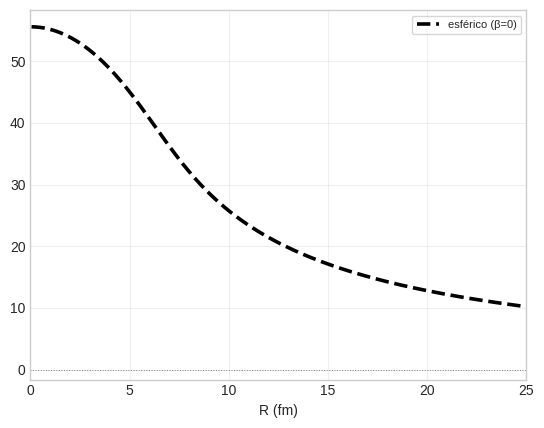

In [9]:
for pidx, lbl, col in zip(phi_idxs, phi_lbls, colors_ph):
    axs[0].plot(R, VC_def[:, pidx], lw=1.8, color=col, label=f'def. φ={lbl}')
plt.plot(R, VC_sph[:, 0], lw=2.6, color='black', ls='--', label='esférico (β=0)')
plt.axhline(0, color='gray', lw=0.7, ls=':')
plt.xlabel("R (fm)")
#plt.ylabel="V (MeV)"
#plt.title="Potencial de Coulomb"
plt.xlim(0, 25)
plt.legend(frameon=True, fontsize=8)
plt.grid(alpha=0.3)